## A summary of model development to correct representational drift

The list of the models:
- single-layer Hebbian network
    - Oja multi-neuron network
    - Sanger multi-neuron network
    - Leen's minimal network

- two-layer Hebbain/anti-Hebbian network with lateral connections
    - Foldiak network
    - Leen's complete activity-dependent network
    - Leen & Freisleben network

The models will be tested to decode the task variable. The task variable will be constructed by the linear combination of the eigenvectors of the input data matrix. 

In [1]:
# import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hebbian.models import OjaNetwork, SangerNetwork, FoldiakPCA, OneShotLeenCompletePCA, OneShotLeenFreislebenPCA
from hebbian.utils import  generate_covariance_matrix, instantiate_samples_by_cov, rotation_matrix_nd, pca_topk, best_match_align_eigenvectors, sign_check, two_phase_training_testing
from sklearn.metrics import r2_score
plt.rcParams['figure.dpi'] = 300

### Data sample generation

In [2]:
N = 64
m = 4
phi_deg = 80.0
n_samples = 15001
X_seed = 0
# get /sigma
# params = np.array([0.1, 0.5, 0.5, 0.001])
params = np.array([0.1, 0.7, 0.4, 0.05])
# params = np.array([0.9, 0.3, 0.3, 0.001])
batch_size = 1
runs = 100


# eigenvalues = np.array([12.0, 5.0, 3.0, 1.8, 1.0, 0.3, 0.1, 0.05])  # Your desired eigenvalues
# eigenvalues = np.array([12.0, 5.0, 4.0, 3.0, 0.001, 0.001, 0.001, 0.001])
# eigenvalues = np.array([12.0, 5.0, 3.0, 0.01])
eigenvalues = np.array([12.0, 5.0, 2.0, 0.5])
Sigma = generate_covariance_matrix(dim=m, eigenvalues=eigenvalues, method="eigenvalues")

R = rotation_matrix_nd(m, axis1=0, axis2=1, phi_rad=np.deg2rad(phi_deg))
plt.show()
Sigma_rot = R @ Sigma @ R.T

X_before = instantiate_samples_by_cov(Sigma, N, m, seed=X_seed, n_samples=n_samples)
X_after = instantiate_samples_by_cov(Sigma_rot, N, m, seed=X_seed, n_samples=n_samples)

pcs_before, _, scores_before = pca_topk(X_before, k=m)
pcs_after, _, scores_after = pca_topk(X_after, k=m)

for i in range(m):
    # get cosine similarity between pcs before and after
    cosine_similarity_before = np.dot(pcs_before[:, i], pcs_after[:, i]) / (np.linalg.norm(pcs_before[:, i]) * np.linalg.norm(pcs_after[:, i]))
    print(f"Cosine similarity between PC{i+1} before and after: {cosine_similarity_before}")

# mat = np.zeros((N, N))
# for i in range(N):
#     for j in range(N):
#         mat[i, j] = np.dot(X_before[i], X_after[j])




task_var_before = np.dot(scores_before, params)
task_var_after = np.dot(scores_after, params)

# figure = plt.figure(figsize=(20, 5))
# plt.plot(range(200), task_var_before[:200], label="Before_task_var")
# plt.plot(range(200), task_var_after[:200], label="After_task_var")
# plt.legend()
# plt.show()

# for i in range(m):
#     figure = plt.figure(figsize=(20, 5))
#     plt.plot(range(N), scores_before[:N, i], label=f"Before_PC_{i}")
#     plt.plot(range(N), scores_after[:N, i], label=f"After_PC_{i}")
#     plt.legend()
#     plt.show()


Cosine similarity between PC1 before and after: 0.7721044618085123
Cosine similarity between PC2 before and after: 0.7015289317901732
Cosine similarity between PC3 before and after: 0.26626867592761955
Cosine similarity between PC4 before and after: 0.581555631295318


### Helper functions of decoding task variable by different models

In [3]:
from tqdm import tqdm
### calculate the task variable across time

# generate values between 0 and 1 for m number
# rng_para = np.random.default_rng(seed=42)
# params = rng_para.random(m)
# params = np.array([0.3, 0.9, 0.3, 0.1, 0.001, 0.0, 0.00, 0.00])

def decoding_task_variable_optimized(model, data, params, task_var=None, pcs=None, scores=None, batch_size=1, output_size=None, runs=runs, graph=True):
    # If output_size wasn't defined in context, assume it matches params or data
    if output_size is None:
        output_size = params.shape[0] # or defined m

    # 1. Pre-calculate PCA once (assuming data doesn't change between runs)
    # This utilizes M1 vectorization efficiently
    if pcs is None or scores is None:
        pcs, _, scores = pca_topk(data, k=output_size)
    
    
    # Initialize storage
    df_task_var_tilde = pd.DataFrame(np.zeros((runs, data.shape[0])))
    df_r_squared = pd.DataFrame(np.zeros((runs, 1)))
    n_samples = data.shape[0]

    # Outer loop: Sequential (as requested)
    # Using tqdm for a clean progress bar
    for run in tqdm(range(runs), desc="Runs"):
        
        # --- OPTIMIZATION START ---
        # We run the training loop strictly for training.
        # No heavy evaluation happens here.
        for step in range(0, n_samples, batch_size):
            X_train = data[step:step+batch_size]
            model.step(X_train) 
            # Note: If you need to incrementally reveal the input matrix 
            # for 'model.transform', logic needs to change, but standard 
            # Hebbian/Oja usually just updates weights here.
            
        # --- EVALUATION ---
        # We only transform and align ONCE per run, after the model 
        # has seen the full dataset for this epoch.
        Y_output = model.transform(data)
        
        try:
            V = model.V
        except AttributeError:
            V = None

        # This expensive step now happens 1 time per run, instead of N times
        order, _, _ = best_match_align_eigenvectors(model.W, V, pcs)
        
        # Reorder the output to match PC order (PC0, PC1, PC2, PC3) FIRST
        # order[i] tells us which PC column i corresponds to
        # np.argsort(order) gives us the inverse permutation to reorder columns
        Y_output_reordered = Y_output[:, np.argsort(order)]

        # Now check signs for the reordered output (columns are now in PC order)
        # For reordered Y_output, column i corresponds to PC i
        signs_reordered = sign_check(Y_output_reordered, scores, model.output_size)

        Y_output_signed = Y_output_reordered * signs_reordered[None, :]
        task_var_tilde = np.dot(Y_output_signed, params)
        
        # Save result
        df_task_var_tilde.iloc[run, :] = task_var_tilde
        r_square = r2_score(task_var, task_var_tilde)
        df_r_squared.iloc[run, :] = r_square
        # --- OPTIMIZATION END ---

        if graph:
            # Calculate correlation for the title
            plt.figure(figsize=(20, 5))
            plt.plot(task_var[:200], label="Target Task Variable")
            plt.plot(task_var_tilde[:200], label="Decoded Task Variable")
            plt.title(f"Run {run+1}, {model.__class__.__name__}, $R^2$ = {df_r_squared.iloc[run, :].values[0]:.2f}")
            plt.legend()
            plt.show()
        
        # Reset model for the next run
        model.reset()

    return df_task_var_tilde, df_r_squared




def decoding_task_variable_optimized_before_after(model, data_before, data_after, params, task_var_before, task_var_after, pcs_before, pcs_after, scores_before, scores_after, batch_size=1, output_size=None, runs=runs, graph=False):
    
    global Y_output_before_signed, Y_output_after_signed, Y_output_on_drifiting_signed
    global task_var_before_tilde, task_var_after_tilde, task_var_on_drifiting_tilde
    # If output_size wasn't defined in context, assume it matches params or data
    if output_size is None:
        output_size = params.shape[0] # or defined m

    # 1. Pre-calculate PCA once (assuming data doesn't change between runs)
    # This utilizes M1 vectorization efficiently
    if pcs_before is None or scores_before is None:
        pcs_before, _, scores_before = pca_topk(data_before, k=output_size)
    if pcs_after is None or scores_after is None:
        pcs_after, _, scores_after = pca_topk(data_after, k=output_size)
    
    
    # Initialize storage
    df_task_var_tilde_before = pd.DataFrame(np.zeros((runs, data_before.shape[0])))
    df_task_var_tilde_after = pd.DataFrame(np.zeros((runs, data_after.shape[0])))
    df_r_squared_before = pd.DataFrame(np.zeros((runs, 1)))
    df_r_squared_after = pd.DataFrame(np.zeros((runs, 1)))
    # df_task_var_on_drifiting = pd.DataFrame(np.zeros((runs, data_after.shape[0])))
    df_r_squared_on_drifiting = pd.DataFrame(np.zeros((runs, 1)))
    df_similarity_before = pd.DataFrame(np.zeros((runs, output_size)))
    df_similarity_after = pd.DataFrame(np.zeros((runs, output_size)))
    df_similarity_on_drifiting = pd.DataFrame(np.zeros((runs, output_size)))

    n_samples = data_before.shape[0]


    def sorted_similarity(order, sim):
        # sort the similarity by the order to get similarity from PC1 to PC4
        combined_lists = zip(order, sim)
        sorted_combined_lists = sorted(combined_lists)  # Sort by PC index (order)
        _, sim_sorted = zip(*sorted_combined_lists)  # Extract similarities in PC order
        sim_sorted = np.array(sim_sorted)  # Convert to numpy array if needed
        return sim_sorted

    # Outer loop: Sequential (as requested)
    # Using tqdm for a clean progress bar
    for run in tqdm(range(runs), desc="Runs"):
        
        # --- OPTIMIZATION START ---
        # We run the training loop strictly for training.
        # No heavy evaluation happens here.
        for step in range(0, n_samples, batch_size):
            X_train = data_before[step:step+batch_size]
            model.step(X_train) 
            # Note: If you need to incrementally reveal the input matrix 
            # for 'model.transform', logic needs to change, but standard 
            # Hebbian/Oja usually just updates weights here.
        # --- OPTIMIZATION END ---
        Y_output_before = model.transform(data_before)
        
        try:
            V = model.V
        except AttributeError:
            V = None
        order, sim, _ = best_match_align_eigenvectors(model.W, V, pcs_before)
        sim_sorted_before = sorted_similarity(order, sim)

        Y_output_before_reordered = Y_output_before[:, np.argsort(order)]
        signs_reordered = sign_check(Y_output_before_reordered, scores_before, model.output_size)
        Y_output_before_signed = Y_output_before_reordered * signs_reordered[None, :]
        task_var_before_tilde = np.dot(Y_output_before_signed, params)


        # evaluating the model in the data after the drift
        Y_output_on_drifiting = model.transform(data_after)
        order, sim, _ = best_match_align_eigenvectors(model.W, V, pcs_after)
        sim_sorted_on_drifiting = sorted_similarity(order, sim)

        Y_output_on_drifiting_reordered = Y_output_on_drifiting[:, np.argsort(order)]
        signs_reordered = sign_check(Y_output_on_drifiting_reordered, scores_after, model.output_size)
        Y_output_on_drifiting_signed = Y_output_on_drifiting_reordered * signs_reordered[None, :]
        task_var_on_drifiting_tilde = np.dot(Y_output_on_drifiting_signed, params)



        for step in range(0, n_samples, batch_size):
            X_train = data_after[step:step+batch_size]
            model.step(X_train) 
            # Note: If you need to incrementally reveal the input matrix 
            # for 'model.transform', logic needs to change, but standard 
            # Hebbian/Oja usually just updates weights here.
            
        # --- EVALUATION ---
        # We only transform and align ONCE per run, after the model 
        # has seen the full dataset for this epoch.
        Y_output_after = model.transform(data_after)
        
        try:
            V = model.V
        except AttributeError:
            V = None

        # This expensive step now happens 1 time per run, instead of N times
        order, sim, _ = best_match_align_eigenvectors(model.W, V, pcs_after)
        sim_sorted_after = sorted_similarity(order, sim)
        
        # Reorder the output to match PC order (PC0, PC1, PC2, PC3) FIRST
        # order[i] tells us which PC column i corresponds to
        # np.argsort(order) gives us the inverse permutation to reorder columns
        Y_output_after_reordered = Y_output_after[:, np.argsort(order)]

        # Now check signs for the reordered output (columns are now in PC order)
        # For reordered Y_output, column i corresponds to PC i
        signs_reordered = sign_check(Y_output_after_reordered, scores_after, model.output_size)

        Y_output_after_signed = Y_output_after_reordered * signs_reordered[None, :]
        task_var_after_tilde = np.dot(Y_output_after_signed, params)
        
        # Save result
        df_task_var_tilde_before.iloc[run, :] = task_var_before_tilde
        r_square_before = r2_score(task_var_before, task_var_before_tilde)
        df_r_squared_before.iloc[run, :] = r_square_before
        df_task_var_tilde_after.iloc[run, :] = task_var_after_tilde
        r_square_after = r2_score(task_var_after, task_var_after_tilde)
        df_r_squared_after.iloc[run, :] = r_square_after
        # df_task_var_on_drifiting.iloc[run, :] = task_var_on_drifiting_tilde
        r_square_on_drifiting = r2_score(task_var_after, task_var_on_drifiting_tilde)
        df_r_squared_on_drifiting.iloc[run, :] = r_square_on_drifiting

        # save the similarity
        df_similarity_before.iloc[run, :] = sim_sorted_before
        df_similarity_after.iloc[run, :] = sim_sorted_after
        df_similarity_on_drifiting.iloc[run, :] = sim_sorted_on_drifiting


        if graph:
            # Calculate correlation for the title
            plt.figure(figsize=(20, 5))
            plt.plot(task_var_after[:200], label="Target Task Variable")
            plt.plot(task_var_before_tilde[:200], label="Decoded Task Variable")
            plt.title(f"Run {run+1}, {model.__class__.__name__}, $R^2$ = {df_r_squared_before.iloc[run, :].values[0]:.2f}")
            plt.legend()
            plt.show()
        
        # Reset model for the next run
        model.reset()
    return {
            "df_task_var_tilde_before": df_task_var_tilde_before,
            "df_task_var_tilde_after": df_task_var_tilde_after, 
            "df_r_squared_before": df_r_squared_before, 
            "df_r_squared_after": df_r_squared_after, 
            "df_r_squared_on_drifiting": df_r_squared_on_drifiting, 
            "df_similarity_before": df_similarity_before, 
            "df_similarity_after": df_similarity_after, 
            "df_similarity_on_drifiting": df_similarity_on_drifiting
        }


def get_task_variable_random(random_model, data, params, pcs=None, scores=None):
    df_task_var_random = pd.DataFrame(np.zeros((runs, data.shape[0])))
    for run in tqdm(range(runs), desc="Runs"):
        # define random network
        random_model.reset()
        Y_output_random = random_model.transform(data)
        if pcs is None or scores is None:
            pcs, _, scores = pca_topk(data, k=m)
        W = random_model.W
        try:
            V = random_model.V
        except AttributeError:
            V= None
        order, _, _ = best_match_align_eigenvectors(W, V=V, eigenvectors=pcs)

        # Reorder the output to match PC order (PC0, PC1, PC2, PC3) FIRST
        Y_output_random_reordered = Y_output_random[:, np.argsort(order)]

        signs = sign_check(Y_output_random_reordered, scores, random_model.output_size)
        # Apply sign corrections
        Y_output_signed_random = Y_output_random_reordered * signs[None, :]
        # Now compute task variable with sign-corrected output
        task_var_random = np.dot(Y_output_signed_random, params)
        df_task_var_random.iloc[run, :] = task_var_random
    return df_task_var_random


def plot_every_task_variable(task_var, df_task_var_tilde, model, display_length=100):
    plt.figure(figsize=(20, 5))

    plt.plot(task_var[:display_length], label="Target Task Variable")
    r_squared_list = []
    for run in range(df_task_var_tilde.shape[0]):
        plt.plot(df_task_var_tilde.iloc[run, :display_length], alpha=0.1)
        # get r-squared of the run
        r_squared = r2_score(task_var, df_task_var_tilde.iloc[run, :])
        r_squared_list.append(r_squared)
    plt.title(f"Every run's task variable, {model.__class__.__name__}, $R^2$ = {np.mean(r_squared_list):.2f} ± {np.std(r_squared_list):.2f}")
    plt.show()


def plot_task_variable_decoding(task_var, mean_df_task_var_random, mean_df_task_var_tilde, std_df_task_var_random, std_df_task_var_tilde, model, display_length=100):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 8))
    
    # Calculate R-squared values
    r_squared_random = r2_score(task_var, mean_df_task_var_random)
    r_squared_tilde = r2_score(task_var, mean_df_task_var_tilde)
    
    # First subplot: task_var and task_var_tilde
    ax1.plot(task_var[:display_length], label="Target Task Variable")
    ax1.plot(mean_df_task_var_tilde[:display_length], label="Decoded Task Variable")
    ax1.fill_between(range(display_length), 
                     mean_df_task_var_tilde[:display_length] - std_df_task_var_tilde[:display_length], 
                     mean_df_task_var_tilde[:display_length] + std_df_task_var_tilde[:display_length], 
                     alpha=0.2, color="orange")
    ax1.set_title(f"After Learning, {model.__class__.__name__}, $R^2$ = {r_squared_tilde:.2f}")
    ax1.legend()
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Task Variable")
    
    # Second subplot: task_var and task_var_random
    ax2.plot(task_var[:display_length], label="Target Task Variable")
    ax2.plot(mean_df_task_var_random[:display_length], color = "green", label="Random Decoded Task Variable")
    ax2.fill_between(range(display_length), 
                     mean_df_task_var_random[:display_length] - std_df_task_var_random[:display_length], 
                     mean_df_task_var_random[:display_length] + std_df_task_var_random[:display_length], 
                     alpha=0.2, color="green")
    ax2.set_title(f"Random Baseline, {model.__class__.__name__}, $R^2$ = {r_squared_random:.2f}")
    ax2.legend()
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Task Variable")
    
    plt.tight_layout()
    plt.show()


### Models testing

In [4]:
leen_paras = dict(
    input_size=N, output_size=m,
    eta_w=5e-5,          # base
    eta_v=3e-4,          # ~4x eta_w
    C=3,
    ema_alpha=0.02,
    symmetrize_V=True,
    seed=None,
    # noise_level=0.001,
    # settling_steps=10
)

leen_freisleben_paras = dict(
    input_size=N, output_size=m,
    eta_w=5e-5,          # ~4x eta_w
    eta_v=3e-4,          # ~4x eta_w
    C=3,
    symmetrize_V=True,
    seed=None,
)


hebb_paras = dict(input_size=N, output_size=m, learning_rate=0.001)
foldiak_paras = dict(input_size=N, output_size=m, eta_w=1e-3, eta_v=1e-2)

models = {
    "OjaNetwork": OjaNetwork(**hebb_paras),
    "SangerNetwork": SangerNetwork(**hebb_paras),
    "FoldiakPCA": FoldiakPCA(**foldiak_paras),
    "OneShotLeenCompletePCA": OneShotLeenCompletePCA(**leen_paras),
    "OneShotLeenFreislebenPCA": OneShotLeenFreislebenPCA(**leen_freisleben_paras),
}

### Alignment between Y outputs and PCs

In [5]:
from hebbian.utils import two_phase_training_testing

# two_phase_training_testing(models["OneShotLeenCompletePCA"], X_before, X_after, m, 
#                             # model_paras_after = model_paras_after, 
#                             runs = 10, graph = True)

### Decoding task variable by different models

In [6]:
def run_experiment(model, data, params, task_var, pcs, scores, runs, batch_size, output_size, plot = True):
    df_task_var_tilde, df_r_squared = decoding_task_variable_optimized(model, data, params, task_var, 
                                                            pcs, scores, 
                                                            batch_size, output_size, 
                                                            runs, graph=False)
    mean_df_task_var_tilde = df_task_var_tilde.mean(axis=0)
    std_df_task_var_tilde = df_task_var_tilde.std(axis=0)

    df_task_var_random = get_task_variable_random(model, data, params, pcs, scores)
    mean_df_task_var_random = df_task_var_random.mean(axis=0)
    std_df_task_var_random = df_task_var_random.std(axis=0)
    if plot:
        plot_every_task_variable(task_var, df_task_var_tilde, model)
        # plot_task_variable_decoding(task_var, 
        #                         mean_df_task_var_random, mean_df_task_var_tilde, 
        #                         std_df_task_var_random, std_df_task_var_tilde, 
        #                         model, display_length=200)


# def run_experiment_two_phases(model, data_before, data_after, params, task_var_before, task_var_after, pcs_before, pcs_after, scores_before, scores_after, runs, batch_size, output_size):
#     res = decoding_task_variable_optimized_before_after(model, data_before, data_after, params, task_var_before, task_var_after, pcs_before, pcs_after, scores_before, scores_after, 
#                                                             batch_size, output_size, 
#                                                             runs, graph=False)
#     return res

### Parallel execution

In [7]:
from joblib import Parallel, delayed
runs = 100 
def run_single_model(model_name, model, X_before, X_after, params, 
                     task_var_before, task_var_after, pcs_before, pcs_after, 
                     scores_before, scores_after, batch_size, output_size, runs):
    """Wrapper function to run a single model experiment"""
    result = decoding_task_variable_optimized_before_after(
        model, data_before=X_before, data_after=X_after, 
        params=params, task_var_before=task_var_before, 
        task_var_after=task_var_after, pcs_before=pcs_before, 
        pcs_after=pcs_after, scores_before=scores_before, 
        scores_after=scores_after, batch_size=batch_size, 
        output_size=output_size, runs=runs
    )
    return model_name, result

# Parallel execution
model_list = ['OjaNetwork', 'FoldiakPCA', 'OneShotLeenCompletePCA', 'OneShotLeenFreislebenPCA', 'SangerNetwork']

results = Parallel(n_jobs=-1, verbose=10)(
    delayed(run_single_model)(
        model, models[model], X_before, X_after, params,
        task_var_before, task_var_after, pcs_before, pcs_after,
        scores_before, scores_after, 1, m, runs
    )
    for model in model_list
)

# Convert results to dictionary
results_dict = {model_name: result for model_name, result in results}

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


Runs: 100%|██████████| 100/100 [00:33<00:00,  2.96it/s]
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   35.0s remaining:   52.5s
Runs: 100%|██████████| 100/100 [01:21<00:00,  1.23it/s]
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:  1.4min remaining:   54.9s
Runs: 100%|██████████| 100/100 [01:24<00:00,  1.19it/s]
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.4min finished


### Bar graph for R^2 scores and PC eigenvector similarity

In [ ]:
PLOT_STYLE = {
    "colors": ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'],
    "bar_edge_linewidth": 3.0,
    "bar_alpha": 1.0,
    "error_linewidth": 1.5,
    "error_color": "black",
    "error_capthick": 1.5,
    "scatter_alpha": 0.2,
    "scatter_size": 20,
    "scatter_jitter_factor": 0.15,
    "label_fontsize": 9,
    "label_fontweight": "bold",
    "tick_fontsize": 12,
    "tick_fontweight": "bold",
    "legend_fontsize": 10,
    "title_fontsize": 14,
    "title_fontweight": "bold",
    "title_pad": 20,
    "ylim_pad_factor": 1.3,
    "group_spacing": 1.0,
    "base_group_width": 0.8,
    "bar_width_scale": 0.8,   # your (0.8 / n_models) * 0.8 factor component
    "figure_size": (12, 6),
}




def compute_positions(n_models, n_conditions, bar_width, group_spacing):
    """
    Returns:
        x_positions: flat list of length n_models * n_conditions
        group_centers: list of group centers (one per condition)
    """
    group_centers = [i * group_spacing for i in range(n_conditions)]
    
    # recompute group width to include the gap (after first model)
    group_width = bar_width * n_models 

    x_positions = []
    for cond_idx in range(n_conditions):
        group_center = group_centers[cond_idx]
        pos = group_center - group_width / 2 + bar_width / 2
        for model_idx in range(n_models):
            x_positions.append(pos)
            pos += bar_width
    return x_positions, group_centers




def plot_grouped_bar_with_scatter(
    ax,
    all_means,
    all_stds,
    raw_data_by_bar,    # list of (x_pos, np.array(values))
    x_positions,
    group_centers,
    model_labels,
    condition_labels,
    ylabel,
    title,
    style=PLOT_STYLE,
):
    colors = style["colors"]
    n_models = len(model_labels)
    n_conditions = len(condition_labels)

    # Assign color to each bar based on its model index
    all_colors = []
    for cond_idx in range(n_conditions):
        for model_idx in range(n_models):
            all_colors.append(colors[model_idx])

    # Bars
    bars = ax.bar(
        x_positions,
        all_means,
        yerr=all_stds,
        width=x_positions[1] - x_positions[0]  # not perfect but okay if spacing is uniform
                if len(x_positions) > 1 else 0.2,
        color="white",
        edgecolor=all_colors,
        linewidth=style["bar_edge_linewidth"],
        alpha=style["bar_alpha"],
        capsize=3,
        error_kw={
            "elinewidth": style["error_linewidth"],
            "ecolor": style["error_color"],
            "capthick": style["error_capthick"],
        },
    )

    # Scatter points
    for (x_pos, data_points) in raw_data_by_bar:
        jitter = np.random.normal(0, (x_positions[1] - x_positions[0]) *
                                     style["scatter_jitter_factor"],
                                  size=len(data_points))
        x_scatter = x_pos + jitter

        # Determine which bar index this x_pos corresponds to
        bar_idx = x_positions.index(x_pos)
        point_color = all_colors[bar_idx]

        ax.scatter(
            x_scatter,
            data_points,
            color=point_color,
            alpha=style["scatter_alpha"],
            s=style["scatter_size"],
            edgecolors="none",
        )

    # Value labels above bars
    for bar, mean_val, std_val in zip(bars, all_means, all_stds):
        height = bar.get_height()
        label_y = max(height, 0) + 0.01  # or handle negative case as you did
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            label_y,
            f"{mean_val:.3f}",
            ha="center",
            va="bottom",
            fontsize=style["label_fontsize"],
            fontweight=style["label_fontweight"],
        )

    # X axis: condition labels
    ax.set_xticks(group_centers)
    ax.set_xticklabels(condition_labels,
                       fontsize=style["tick_fontsize"],
                       fontweight=style["tick_fontweight"])

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="white", edgecolor=colors[i],
              linewidth=2, label=model_labels[i])
        for i in range(len(model_labels))
    ]
    ax.legend(handles=legend_elements,
              loc="upper left",
              fontsize=style["legend_fontsize"])

    # Y, title
    ax.set_ylabel(ylabel,
                  fontsize=style["tick_fontsize"],
                  fontweight=style["tick_fontweight"])
    ax.set_title(
        title,
        fontsize=style["title_fontsize"],
        fontweight=style["title_fontweight"],
        pad=style["title_pad"],
    )

    # Y limits with padding
    if all_means:
        max_val = max(m + s for m, s in zip(all_means, all_stds))
        ax.set_ylim([0, max_val * style["ylim_pad_factor"]])

    # X limits
    group_spacing = PLOT_STYLE["group_spacing"]
    ax.set_xlim([-0.5, (len(condition_labels) - 1) * group_spacing + 0.5])

    # Clean up spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)



def plot_grouped_bar_with_scatter(
    ax,
    all_means,
    all_stds,
    raw_data_by_bar,    # list of (x_pos, np.array(values))
    x_positions,
    group_centers,
    model_labels,
    condition_labels,
    ylabel,
    title,
    style=PLOT_STYLE,
):
    colors = style["colors"]
    n_models = len(model_labels)
    n_conditions = len(condition_labels)

    # Assign color to each bar based on its model index
    all_colors = []
    for cond_idx in range(n_conditions):
        for model_idx in range(n_models):
            all_colors.append(colors[model_idx])

    # Bars
    bars = ax.bar(
        x_positions,
        all_means,
        yerr=all_stds,
        width=x_positions[1] - x_positions[0]  # not perfect but okay if spacing is uniform
                if len(x_positions) > 1 else 0.2,
        color="white",
        edgecolor=all_colors,
        linewidth=style["bar_edge_linewidth"],
        alpha=style["bar_alpha"],
        capsize=3,
        error_kw={
            "elinewidth": style["error_linewidth"],
            "ecolor": style["error_color"],
            "capthick": style["error_capthick"],
        },
    )

    # Scatter points
    for (x_pos, data_points) in raw_data_by_bar:
        jitter = np.random.normal(0, (x_positions[1] - x_positions[0]) *
                                     style["scatter_jitter_factor"],
                                  size=len(data_points))
        x_scatter = x_pos + jitter

        # Determine which bar index this x_pos corresponds to
        bar_idx = x_positions.index(x_pos)
        point_color = all_colors[bar_idx]

        ax.scatter(
            x_scatter,
            data_points,
            color=point_color,
            alpha=style["scatter_alpha"],
            s=style["scatter_size"],
            edgecolors="none",
        )

    # Value labels above bars
    for bar, mean_val, std_val in zip(bars, all_means, all_stds):
        height = bar.get_height()
        label_y = max(height, 0) + 0.01  # or handle negative case as you did
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            label_y,
            f"{mean_val:.3f}",
            ha="center",
            va="bottom",
            fontsize=style["label_fontsize"],
            fontweight=style["label_fontweight"],
        )

    # X axis: condition labels
    ax.set_xticks(group_centers)
    ax.set_xticklabels(condition_labels,
                       fontsize=style["tick_fontsize"],
                       fontweight=style["tick_fontweight"])

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="white", edgecolor=colors[i],
              linewidth=2, label=model_labels[i])
        for i in range(len(model_labels))
    ]
    # ax.legend(handles=legend_elements,
    #           loc="upper left",
    #           fontsize=style["legend_fontsize"])

    # Y, title
    ax.set_ylabel(ylabel,
                  fontsize=style["tick_fontsize"],
                  fontweight=style["tick_fontweight"])
    ax.set_title(
        title,
        fontsize=style["title_fontsize"],
        fontweight=style["title_fontweight"],
        pad=style["title_pad"],
    )

    # Y limits with padding
    if all_means:
        max_val = max(m + s for m, s in zip(all_means, all_stds))
        ax.set_ylim([0, max_val * style["ylim_pad_factor"]])

    # X limits
    group_spacing = PLOT_STYLE["group_spacing"]
    ax.set_xlim([-0.5, (len(condition_labels) - 1) * group_spacing + 0.5])

    # Clean up spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

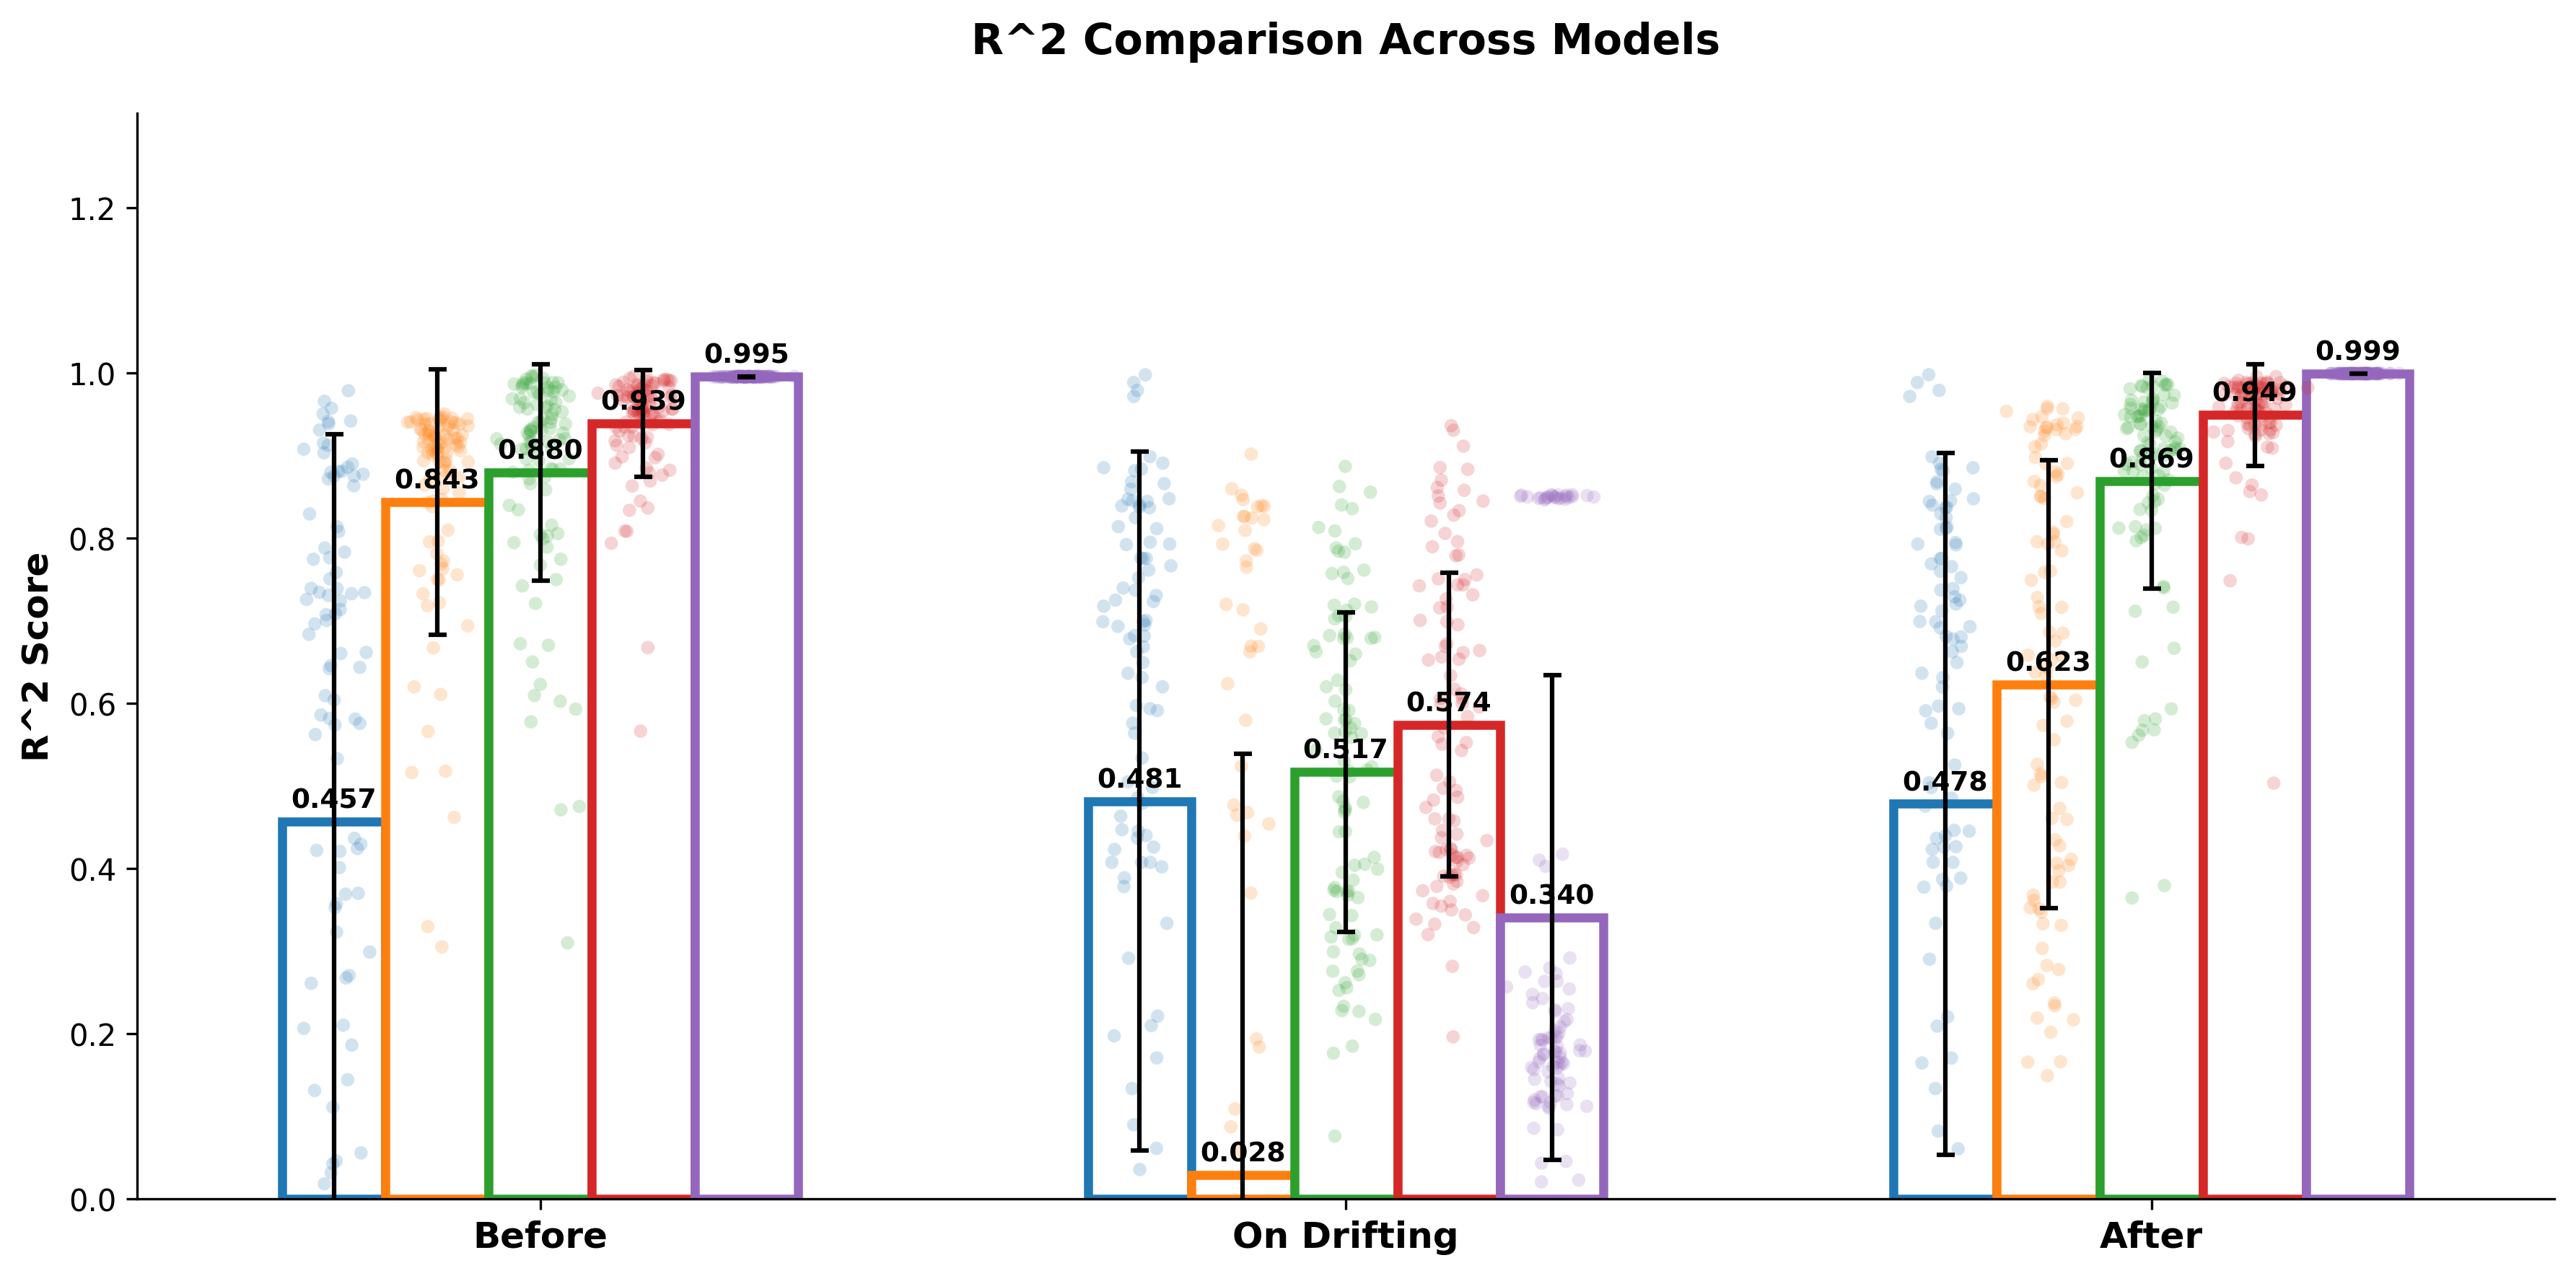

In [18]:
# Define models and their display names
model_mapping = {
    'OjaNetwork': 'OjaNetwork',
    'FoldiakPCA': 'Foldiak',
    'OneShotLeenCompletePCA': 'Leen',
    'OneShotLeenFreislebenPCA': 'LeenFreisleben',
    'SangerNetwork': 'SangerNetwork'
}

# Extract R^2 data for each model and condition
possible_keys = {
    'before': ['r_squared_before', 'df_r_squared_before', 'R_squared_before'],
    'on_drifting': ['r_squared_on_drifiting', 'df_r_squared_on_drifiting', 'r_squared_on_drifiting'],
    'after': ['r_squared_after', 'df_r_squared_after', 'R_squared_after']
}

def find_key(model_dict, possible_list):
    for key in possible_list:
        if key in model_dict:
            return key
    return None

# Prepare data (including raw data for individual points)
means = {'before': [], 'on_drifting': [], 'after': []}
stds = {'before': [], 'on_drifting': [], 'after': []}
raw_data = {'before': [], 'on_drifting': [], 'after': []}  # Store raw data for scatter
model_labels = []

for model_key, model_display in model_mapping.items():
    if model_key in results_dict:
        model_labels.append(model_display)
        model_data = results_dict[model_key]
        
        for cond in ['before', 'on_drifting', 'after']:
            key = find_key(model_data, possible_keys[cond])
            if key:
                r2_data = model_data[key]
                if isinstance(r2_data, pd.DataFrame):
                    values = r2_data.values.flatten()
                else:
                    values = np.array(r2_data).flatten()
                means[cond].append(np.mean(values))
                stds[cond].append(np.std(values))
                raw_data[cond].append(values)  # Store raw values for scatter plot


# --- after you have means, stds, raw_data, model_labels prepared ---

n_models = len(model_labels)
n_conditions = 3
condition_labels = ["Before", "On Drifting", "After"]

bar_width = (0.8 / n_models) * PLOT_STYLE["bar_width_scale"]
group_spacing = PLOT_STYLE["group_spacing"]
# extra_gap = bar_width * PLOT_STYLE["extra_gap_factor"]

x_positions, group_centers = compute_positions(
    n_models, n_conditions, bar_width, group_spacing
)

# Flatten data to per-bar order
all_means = []
all_stds = []
raw_data_by_bar = []

for cond_idx, cond in enumerate(["before", "on_drifting", "after"]):
    for model_idx in range(n_models):
        all_means.append(means[cond][model_idx])
        all_stds.append(stds[cond][model_idx])
        x_pos = x_positions[cond_idx * n_models + model_idx]
        raw_data_by_bar.append((x_pos, raw_data[cond][model_idx]))

fig, ax = plt.subplots(1, 1, figsize=PLOT_STYLE["figure_size"], dpi=300)
plot_grouped_bar_with_scatter(
    ax=ax,
    all_means=all_means,
    all_stds=all_stds,
    raw_data_by_bar=raw_data_by_bar,
    x_positions=x_positions,
    group_centers=group_centers,
    model_labels=model_labels,
    condition_labels=condition_labels,
    ylabel="R^2 Score",
    title="R^2 Comparison Across Models",
)
plt.tight_layout()
plt.show()

TypeError: plot_grouped_bar_with_scatter() missing 1 required positional argument: 'title'

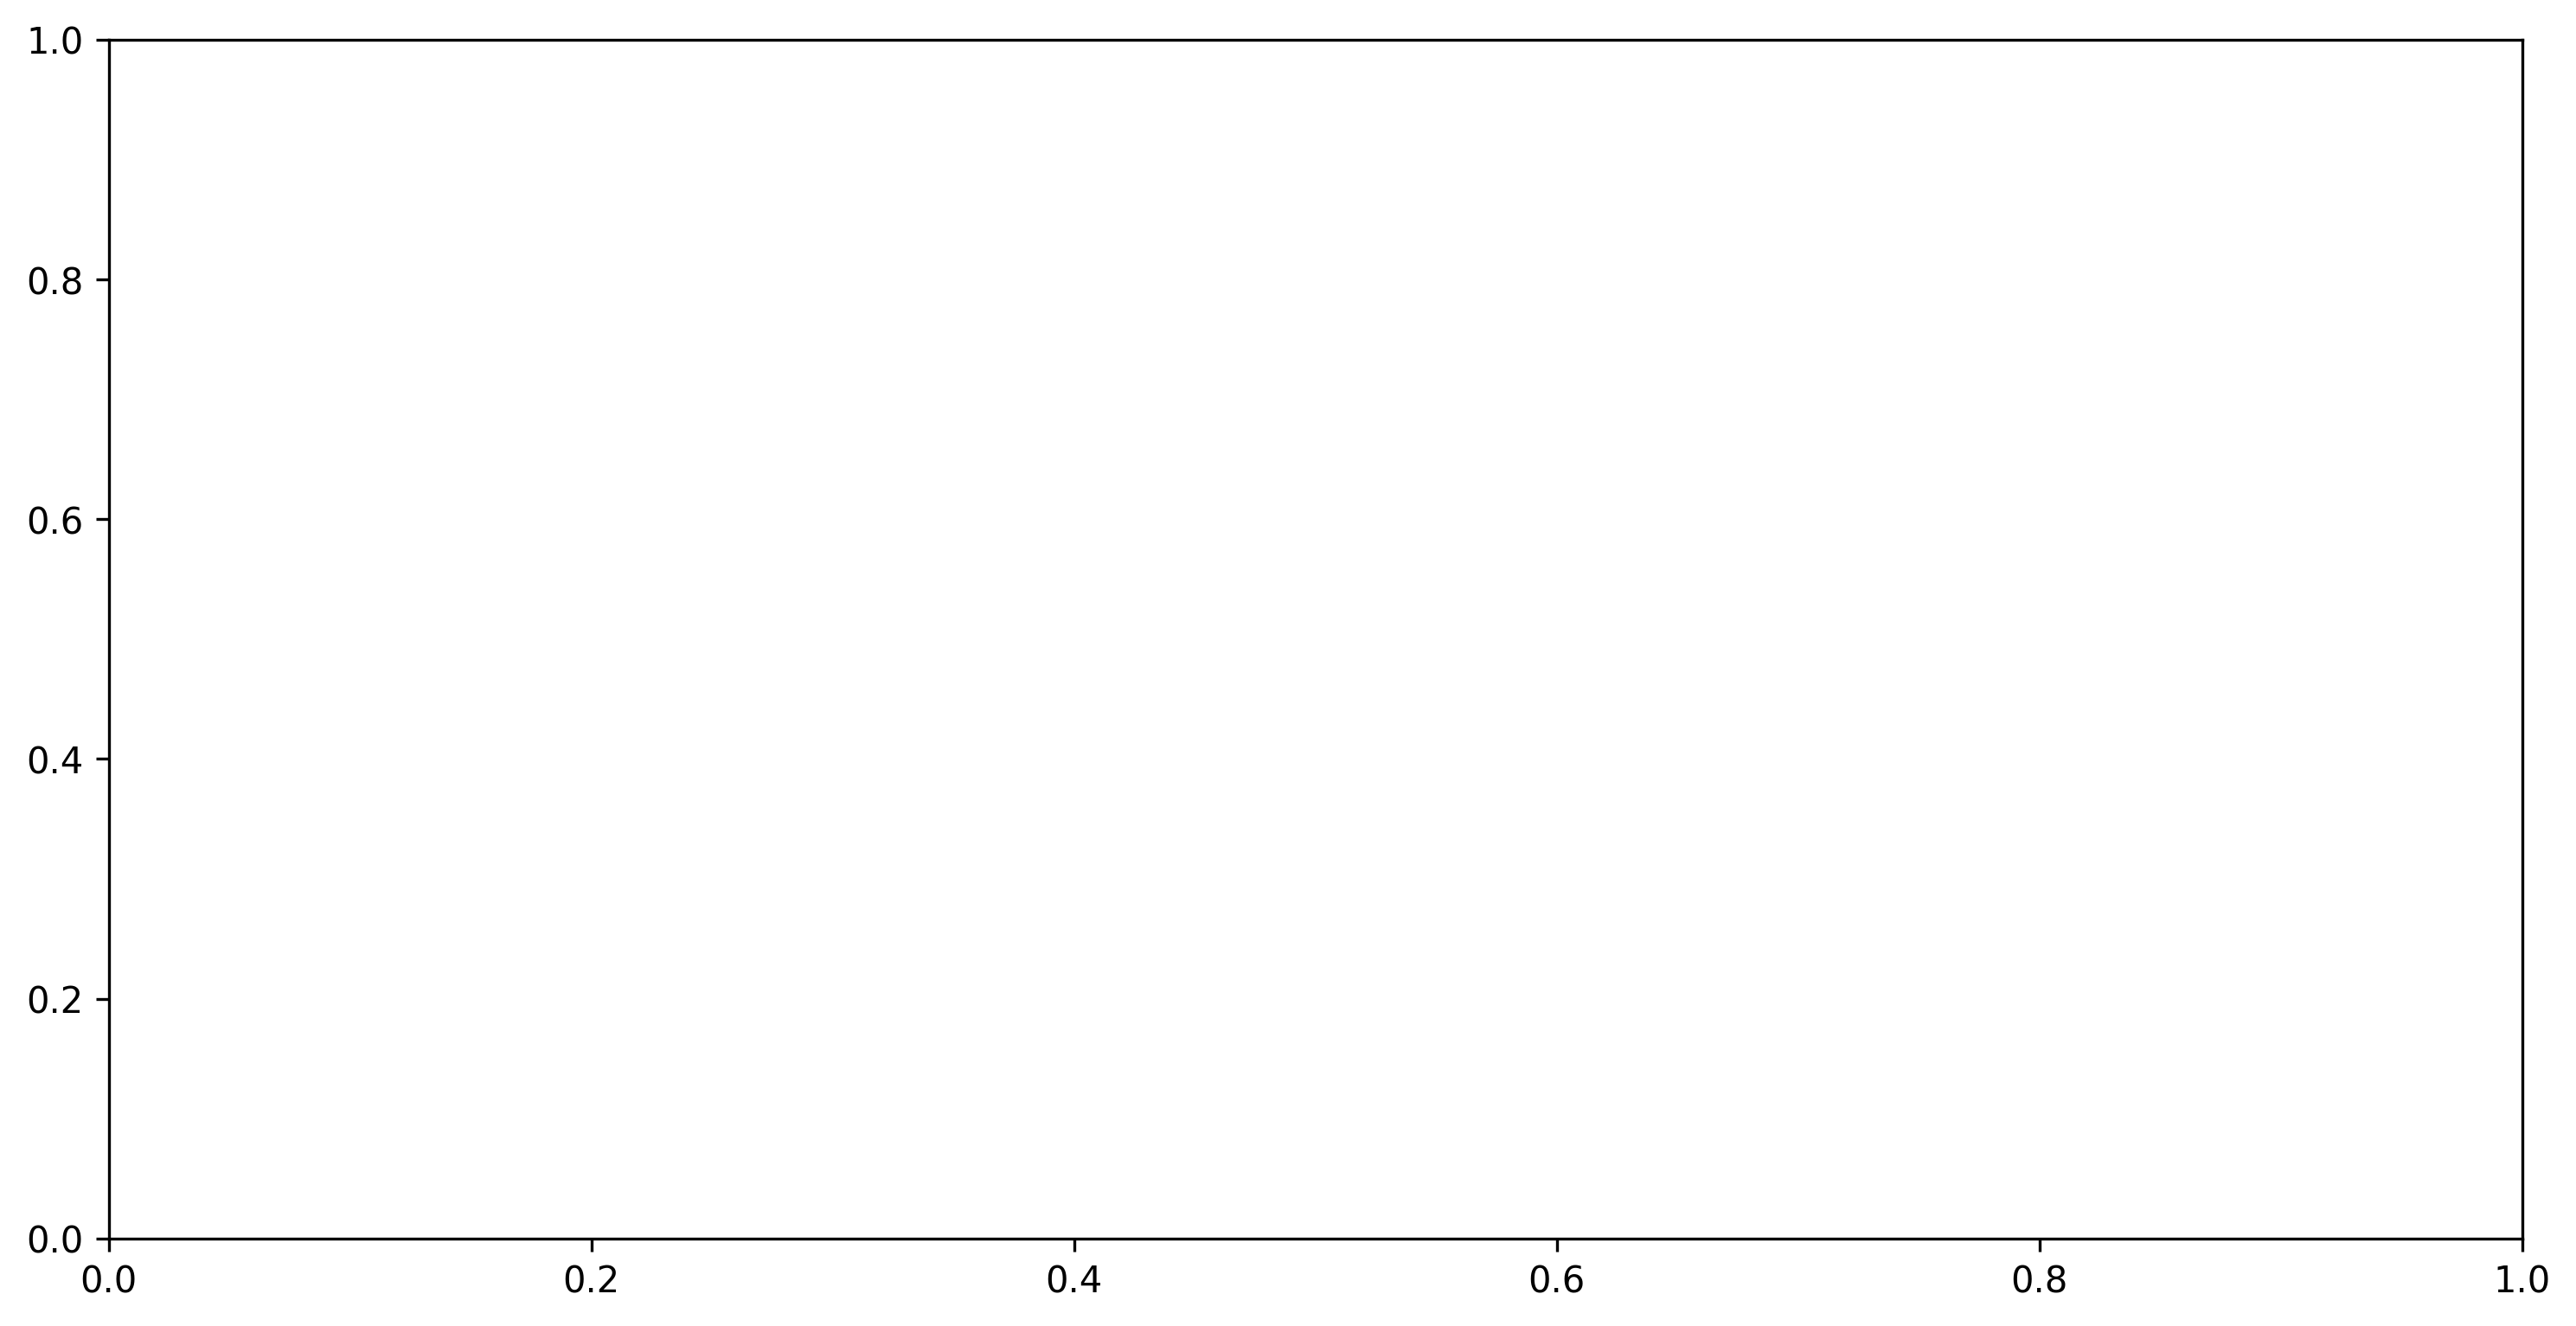

In [ ]:
# Extract similarity data for each model and condition
possible_keys = {
    'before': ['similarity_before', 'df_similarity_before'],
    'on_drifting': ['similarity_on_drifiting', 'df_similarity_on_drifiting'],
    'after': ['similarity_after', 'df_similarity_after']
}

# Prepare data for each PC (PC1-PC4) - including raw data
n_pcs = m
means_by_pc = {pc: {'before': [], 'on_drifting': [], 'after': []} for pc in range(n_pcs)}
stds_by_pc = {pc: {'before': [], 'on_drifting': [], 'after': []} for pc in range(n_pcs)}
raw_data_by_pc = {pc: {'before': [], 'on_drifting': [], 'after': []} for pc in range(n_pcs)}  # Store raw data
model_labels = []

for model_key, model_display in model_mapping.items():
    if model_key in results_dict:
        model_labels.append(model_display)
        model_data = results_dict[model_key]
        
        for cond in ['before', 'on_drifting', 'after']:
            key = find_key(model_data, possible_keys[cond])
            if key:
                similarity_data = model_data[key]
                if isinstance(similarity_data, pd.DataFrame):
                    # Each row is a run, each column is a PC
                    values = similarity_data.values  # Shape: (runs, n_pcs)
                else:
                    values = np.array(similarity_data)
                    if values.ndim == 1:
                        values = values.reshape(-1, n_pcs)
                
                # Extract mean, std, and raw data for each PC
                for pc in range(n_pcs):
                    pc_values = values[:, pc] if values.ndim > 1 else values
                    means_by_pc[pc][cond].append(np.mean(pc_values))
                    stds_by_pc[pc][cond].append(np.std(pc_values))
                    raw_data_by_pc[pc][cond].append(pc_values)  # Store raw values



# Create a separate figure for each PC
for pc_idx in range(n_pcs):
    fig, ax = plt.subplots(1, 1, figsize=PLOT_STYLE["figure_size"], dpi=300)

    n_models = len(model_labels)
    n_conditions = 3
    condition_labels = ["Before", "On Drifting", "After"]

    bar_width = (0.8 / n_models) * PLOT_STYLE["bar_width_scale"]
    group_spacing = PLOT_STYLE["group_spacing"]

    x_positions, group_centers = compute_positions(
        n_models, n_conditions, bar_width, group_spacing
    )

    all_means = []
    all_stds = []
    raw_data_by_bar = []

    for cond_idx, cond in enumerate(["before", "on_drifting", "after"]):
        for model_idx in range(n_models):
            all_means.append(means_by_pc[pc_idx][cond][model_idx])
            all_stds.append(stds_by_pc[pc_idx][cond][model_idx])
            x_pos = x_positions[cond_idx * n_models + model_idx]
            raw_data_by_bar.append(
                (x_pos, raw_data_by_pc[pc_idx][cond][model_idx])
            )

    plot_grouped_bar_with_scatter(
        ax=ax,
        all_means=all_means,
        all_stds=all_stds,
        raw_data_by_bar=raw_data_by_bar,
        x_positions=x_positions,
        group_centers=group_centers,
        model_labels=model_labels,
        condition_labels=condition_labels,
        ylabel=f"Eigenvector PC{pc_idx + 1} Alignment",
        title=f" ",
    )
    plt.tight_layout()
    plt.show()

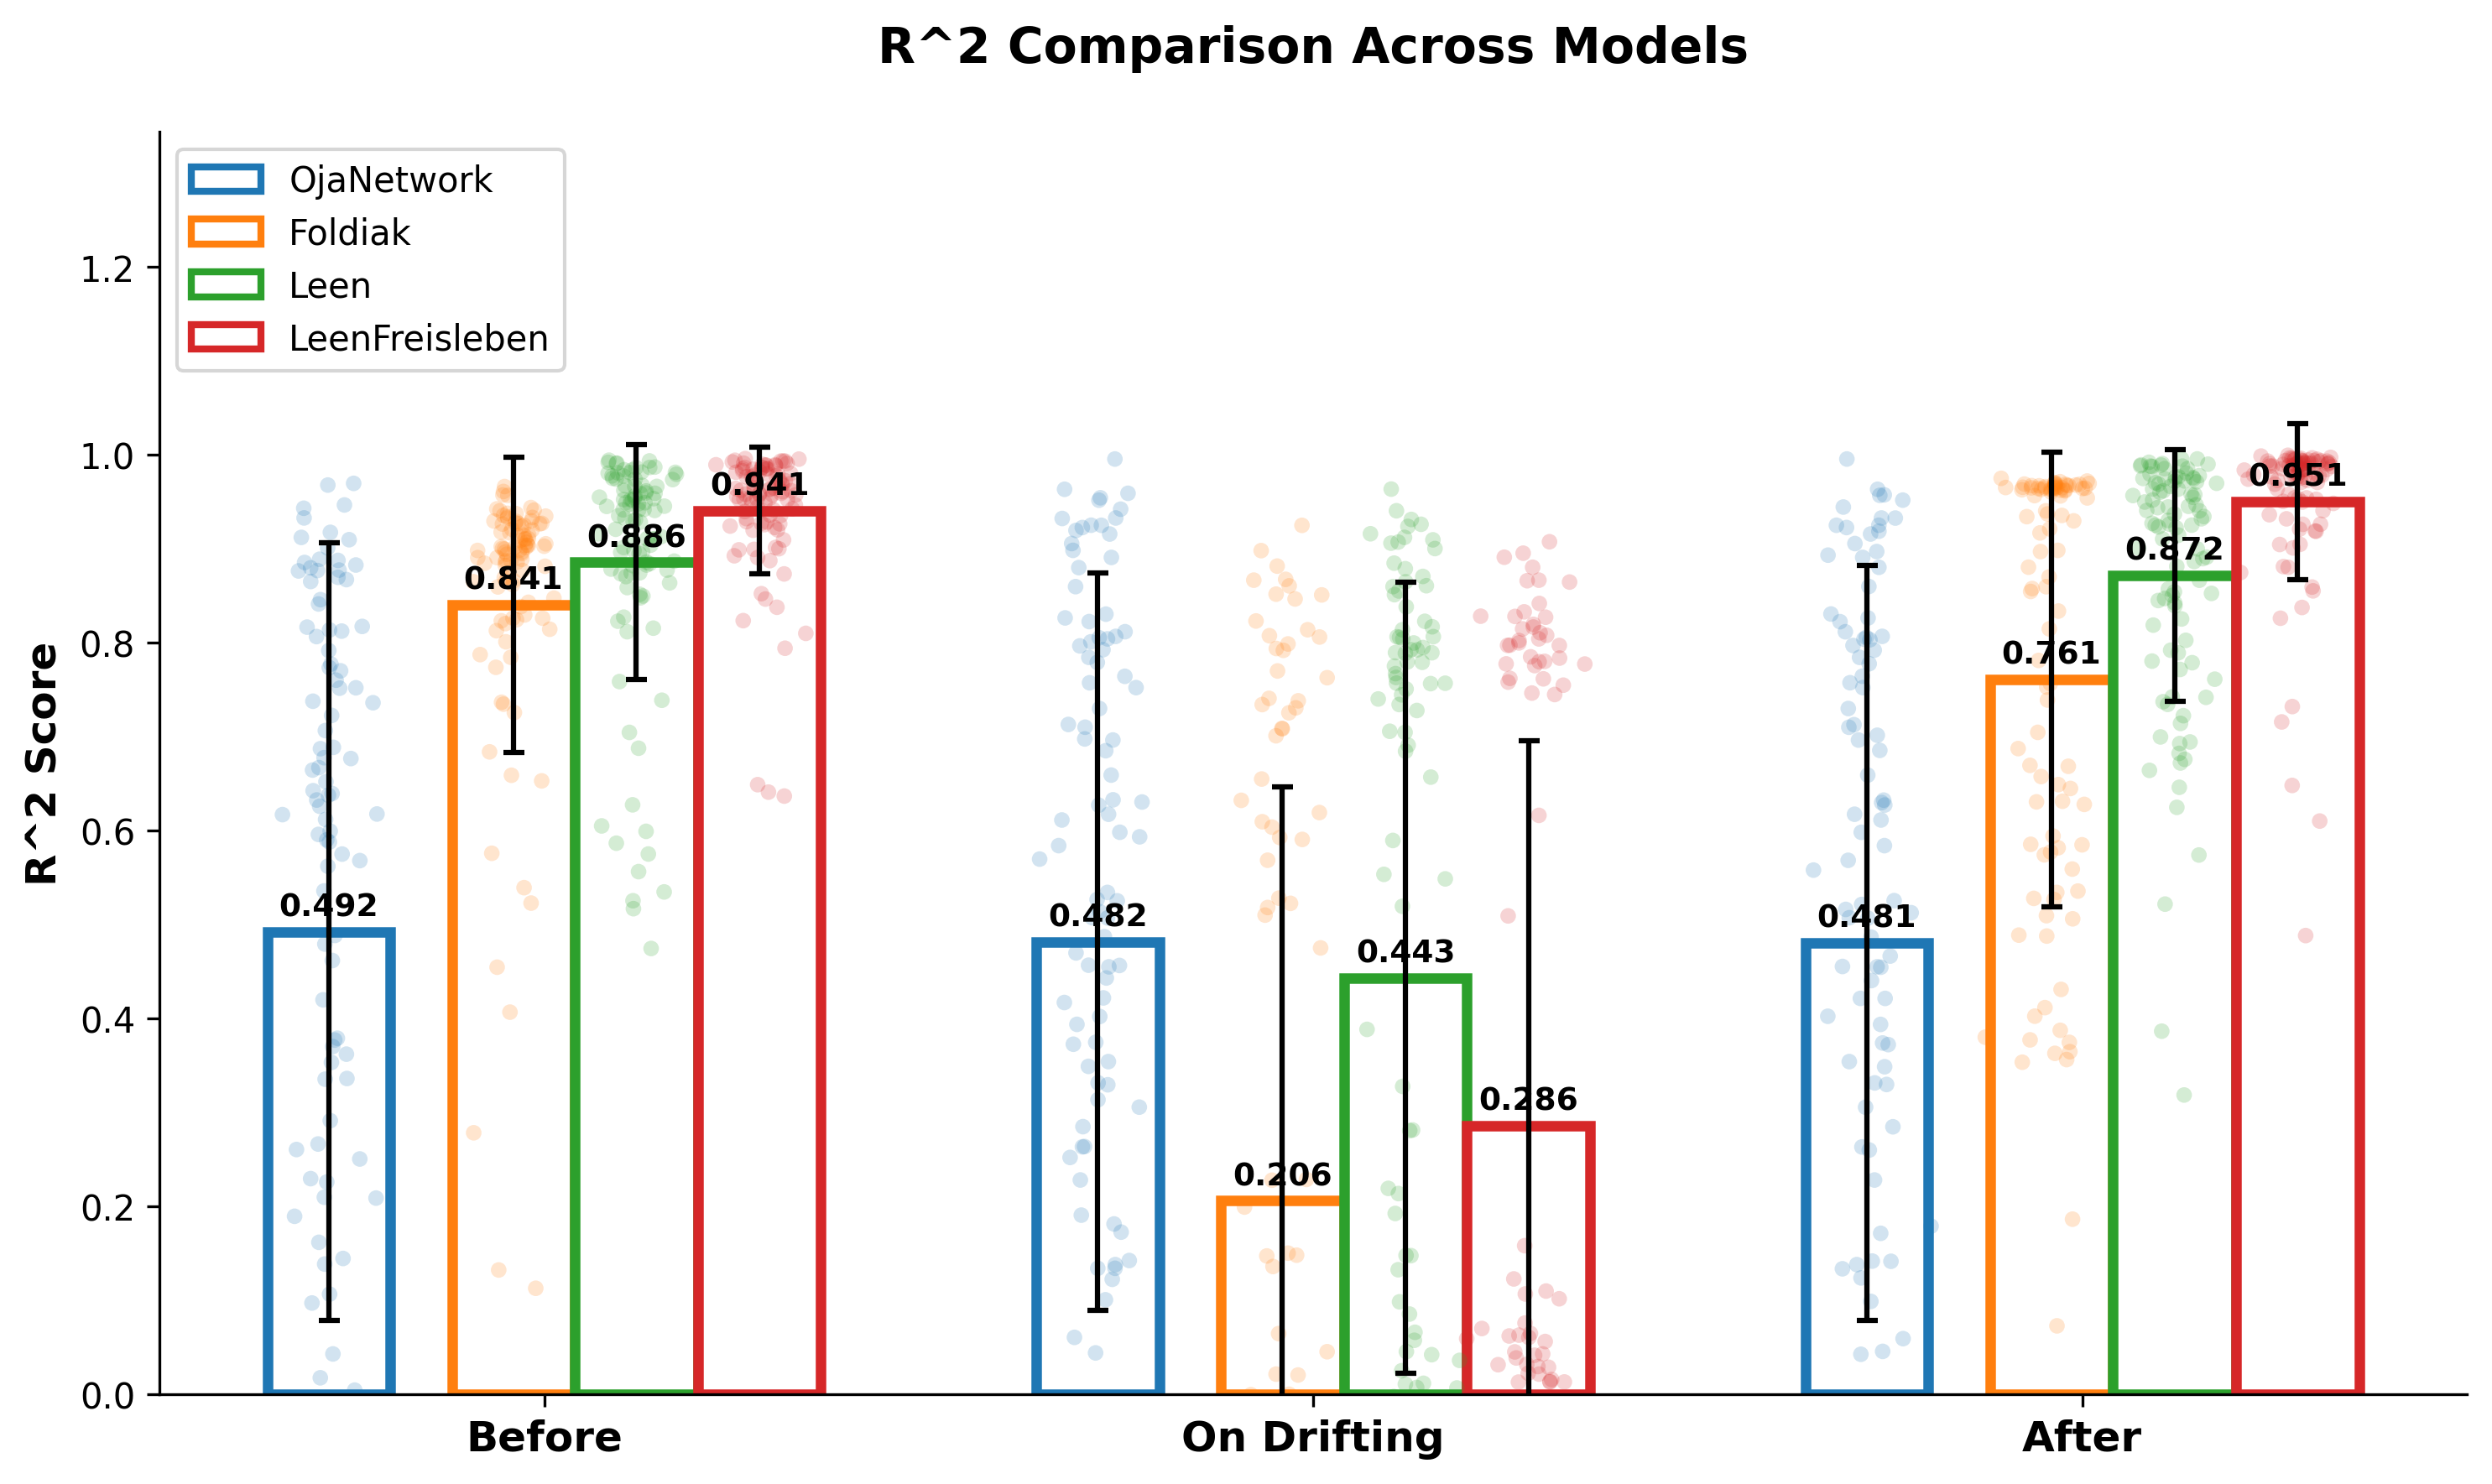

In [ ]:


# Create single figure
fig, ax = plt.subplots(1, 1, figsize=(10, 6), dpi=300)

# Define colors for each model
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red

# Set up positions
n_models = len(model_labels)
n_conditions = 3
condition_labels = ['Before', 'On Drifting', 'After']

# Calculate bar positions
bar_width = (0.8 / n_models) * 0.8
group_width = 0.8
group_spacing = 1.0


# Define gap after OjaNetwork
extra_gap = bar_width * 0.5  # adjust as needed

# Recompute group width to include the gap
group_width = bar_width * n_models + extra_gap

# Calculate x positions for each bar with the custom gap
x_positions = []
for cond_idx in range(n_conditions):
    group_center = cond_idx * group_spacing
    pos = group_center - group_width / 2 + bar_width / 2
    for model_idx in range(n_models):
        x_positions.append(pos)
        if model_idx == 0:        # after OjaNetwork
            pos += bar_width + extra_gap
        else:
            pos += bar_width


# Calculate x positions for each bar
# x_positions = []
# for cond_idx in range(n_conditions):
#     group_center = cond_idx * group_spacing
#     group_start = group_center - group_width / 2 + bar_width / 2
#     for model_idx in range(n_models):
#         x_pos = group_start + model_idx * bar_width
#         x_positions.append(x_pos)

# Flatten the data for plotting
all_means = []
all_stds = []
all_colors = []
all_raw_data = []  # Store raw data with corresponding x positions

for cond_idx, cond in enumerate(['before', 'on_drifting', 'after']):
    for model_idx in range(n_models):
        all_means.append(means[cond][model_idx])
        all_stds.append(stds[cond][model_idx])
        all_colors.append(colors[model_idx])
        # Store raw data with its x position
        x_pos = x_positions[cond_idx * n_models + model_idx]
        all_raw_data.append((x_pos, raw_data[cond][model_idx]))

# Create bars with empty fill and colored edges
bars = ax.bar(x_positions, all_means, yerr=all_stds,
              width=bar_width,
              color='white',  # Fill color is white
              edgecolor=all_colors,  # Edge color matches the original colors
              linewidth=3.0,  # Make edges more visible
              alpha=1.0,  # Full opacity for edges
              capsize=3,
              error_kw={'elinewidth': 1.5, 'ecolor': 'black', 'capthick': 1.5})

# Add individual data points with jitter
for x_pos, data_points in all_raw_data:
    # Add small random jitter to x position for better visibility
    jitter = np.random.normal(0, bar_width * 0.15, len(data_points))
    x_scatter = x_pos + jitter
    
    # Find the corresponding color
    idx = x_positions.index(x_pos)
    point_color = all_colors[idx]
    
    # Plot individual points
    ax.scatter(x_scatter, data_points, 
              color=point_color, 
              alpha=0.2, 
              s=20,  # Point size
              edgecolors='none')  # No edge on points

# Add value labels above error bars (or above 0 if negative)
for bar, mean_val, std_val in zip(bars, all_means, all_stds):
    height = bar.get_height()
    if mean_val < 0:
        # If value is negative, place label above 0
        label_y = 0.01
    else:
        # If value is positive, place label above error bar
        label_y = height + 0.01
    ax.text(bar.get_x() + bar.get_width()/2., label_y,
           f'{mean_val:.3f}',
           ha='center', va='bottom', fontsize=9, fontweight='bold')

# Set x-axis labels
group_centers = [i * group_spacing for i in range(n_conditions)]
ax.set_xticks(group_centers)
ax.set_xticklabels(condition_labels, fontsize=12, fontweight='bold')


# Add legend for models
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='white', edgecolor=colors[i], linewidth=2,
                         label=model_labels[i]) for i in range(n_models)]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

# Customize the plot
ax.set_ylabel('R^2 Score', fontsize=12, fontweight='bold')
ax.set_title('R^2 Comparison Across Models', fontsize=14, fontweight='bold', pad=20)
max_val = max([m + s for m, s in zip(all_means, all_stds)]) if all_means else 1
ax.set_ylim([0, max_val * 1.3])
ax.set_xlim([-0.5, (n_conditions - 1) * group_spacing + 0.5])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

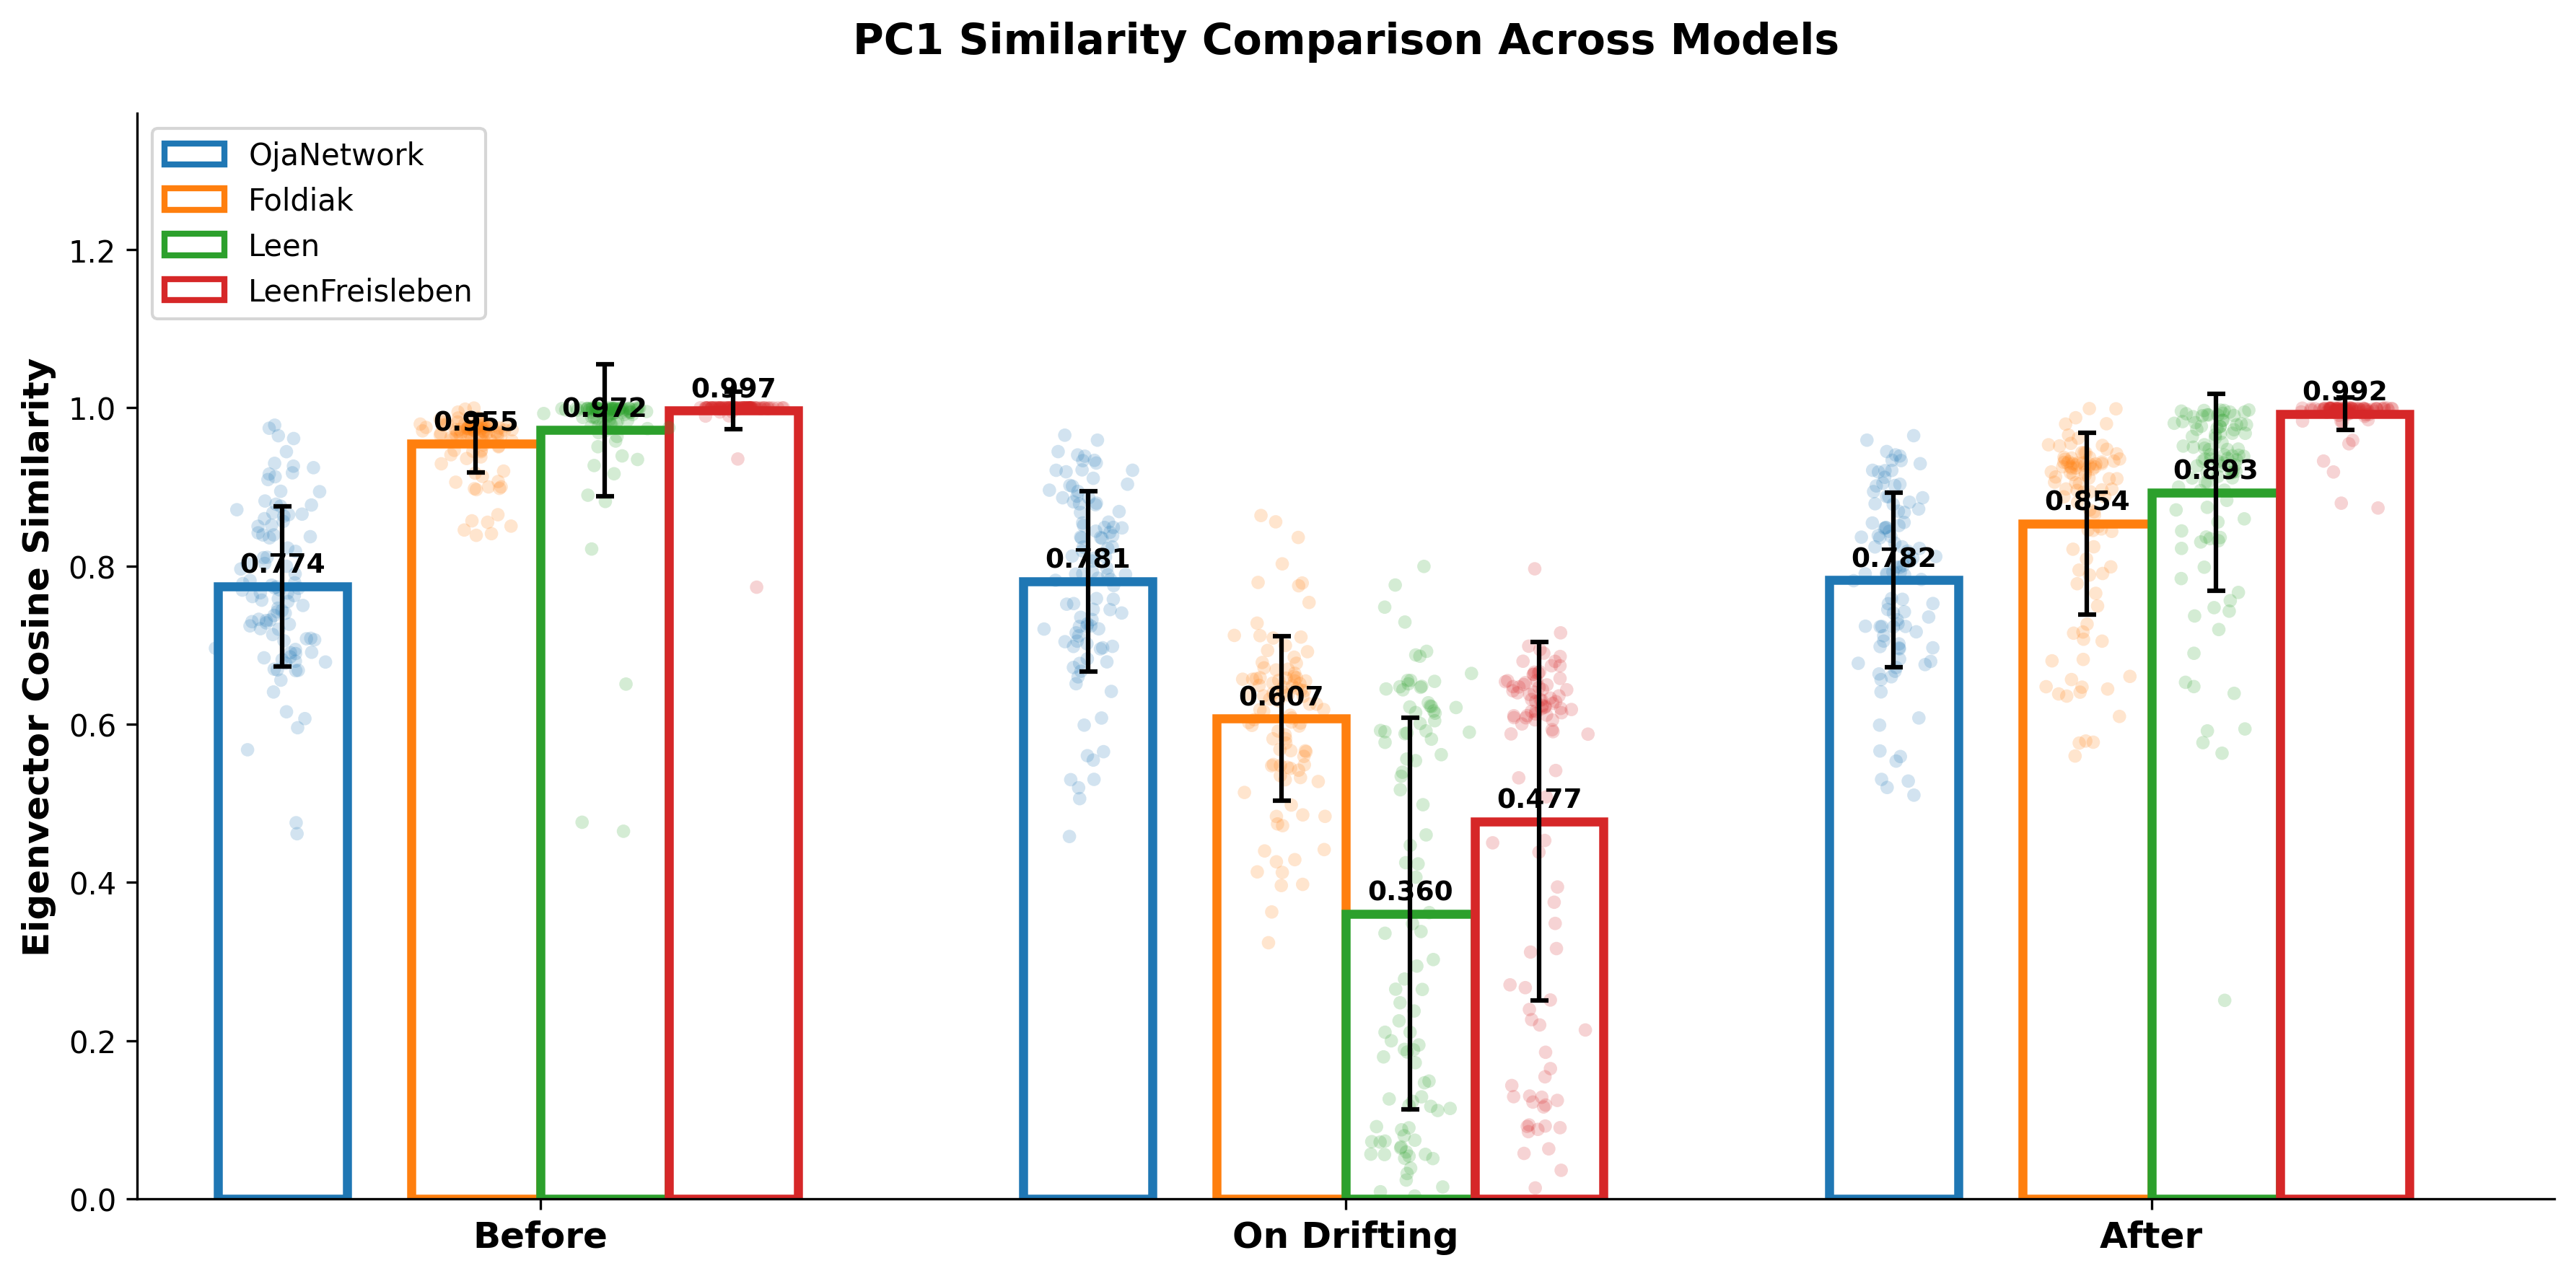

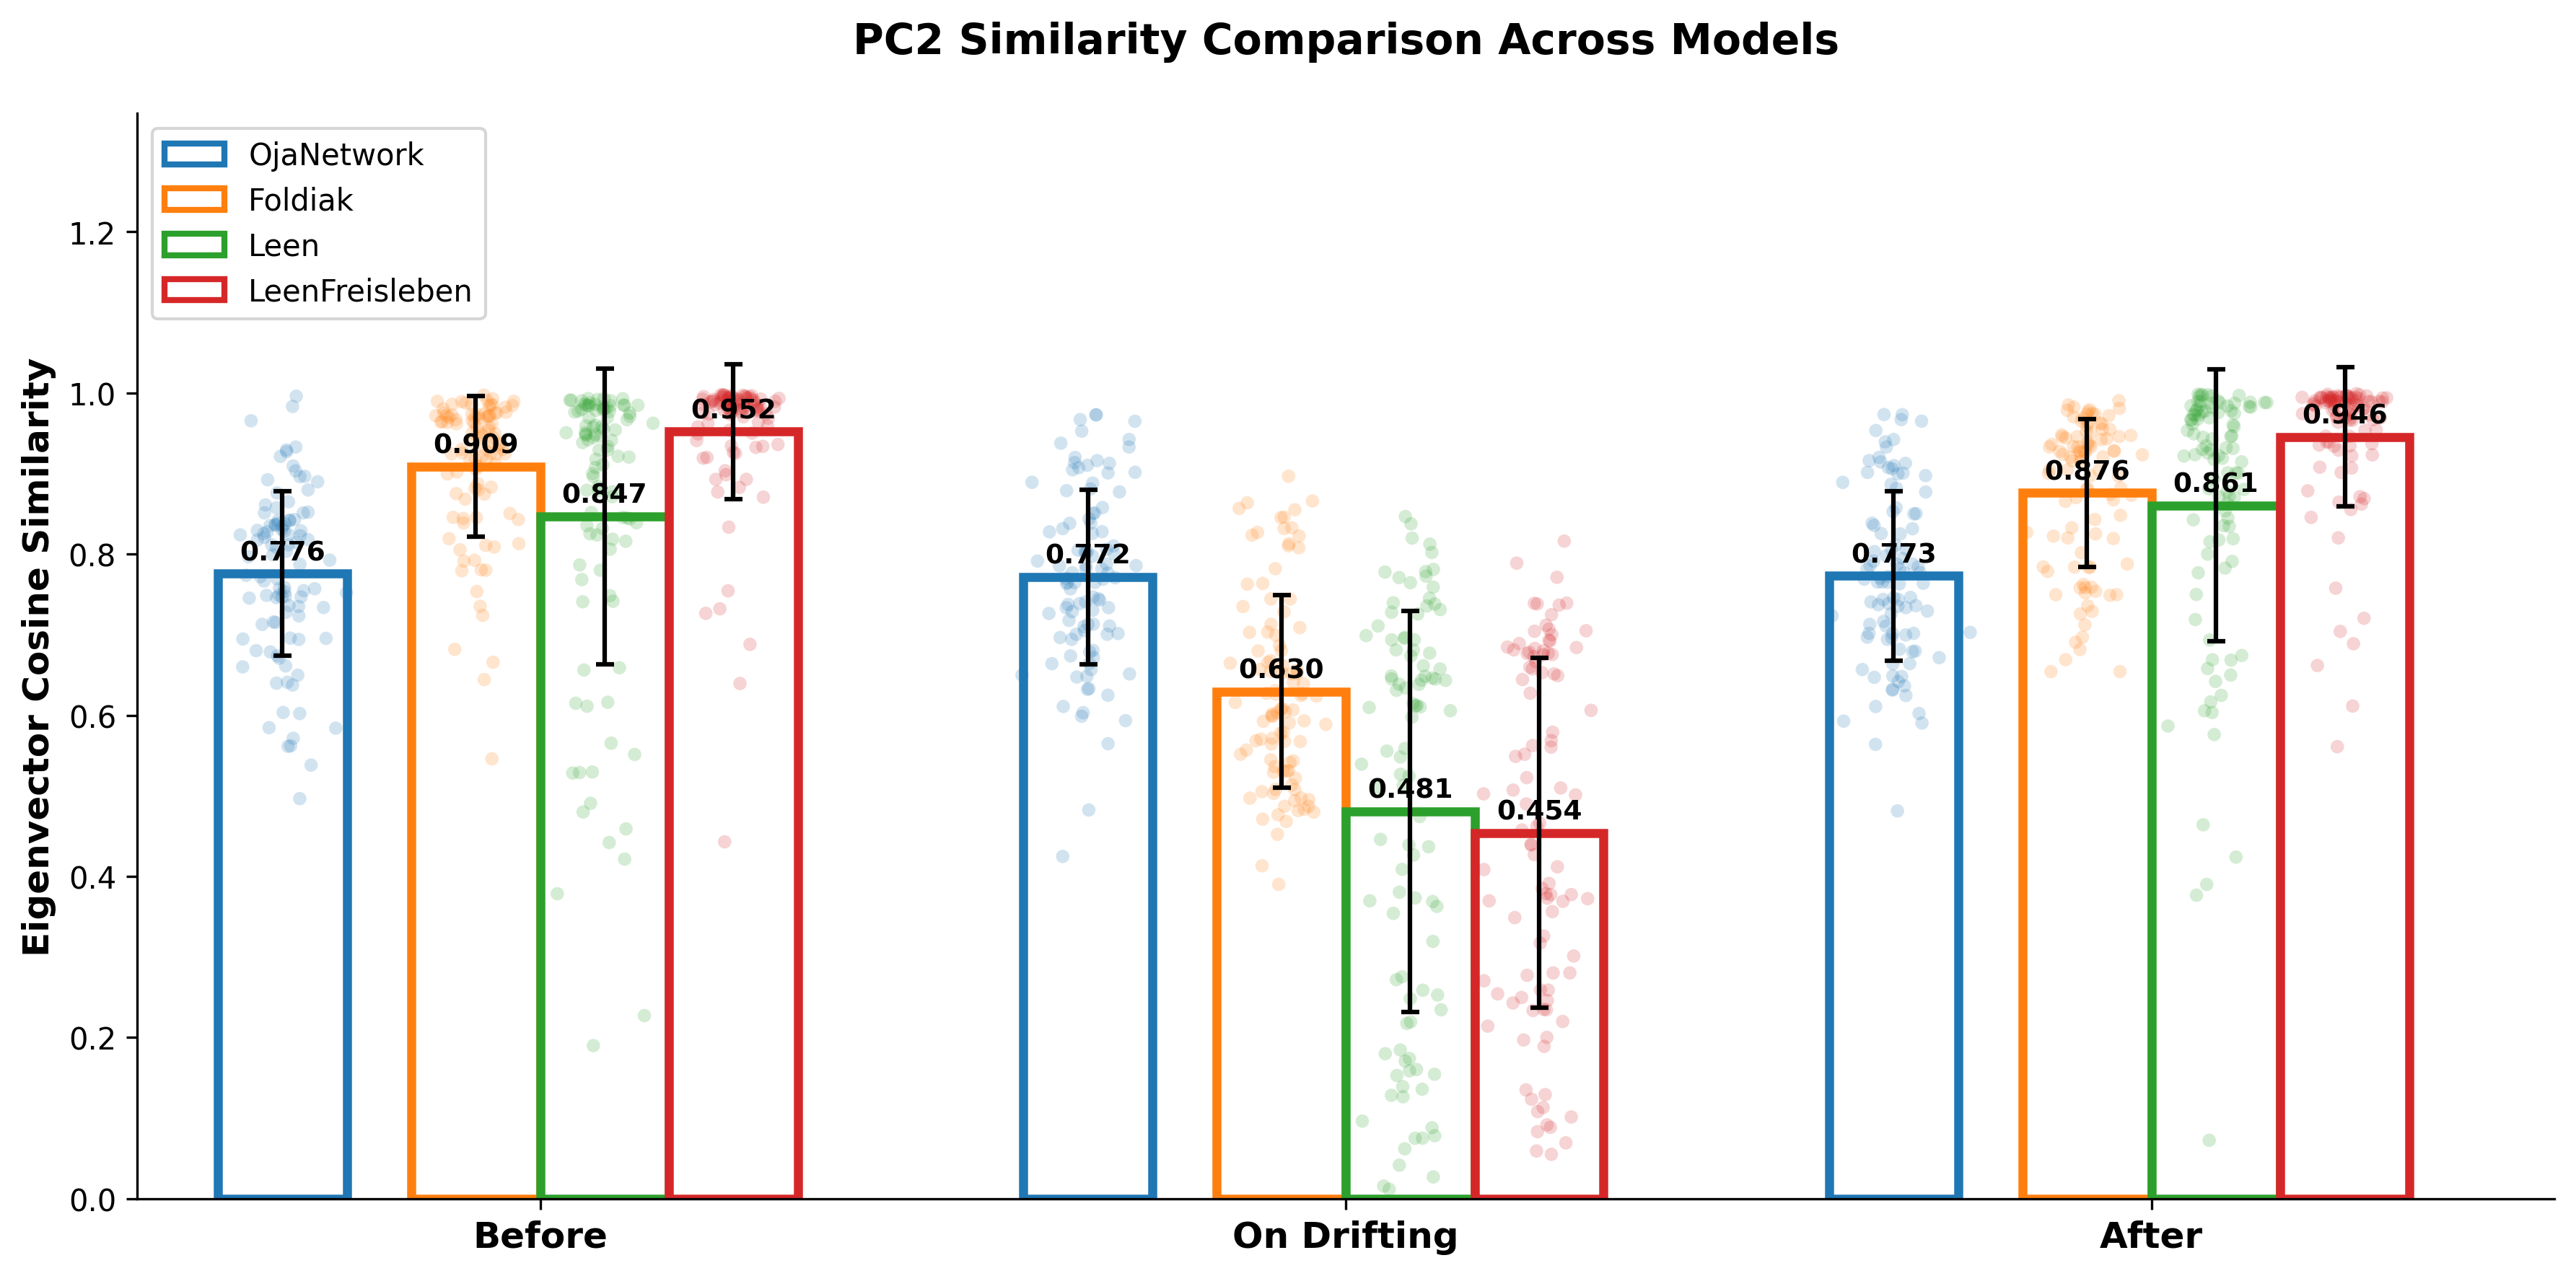

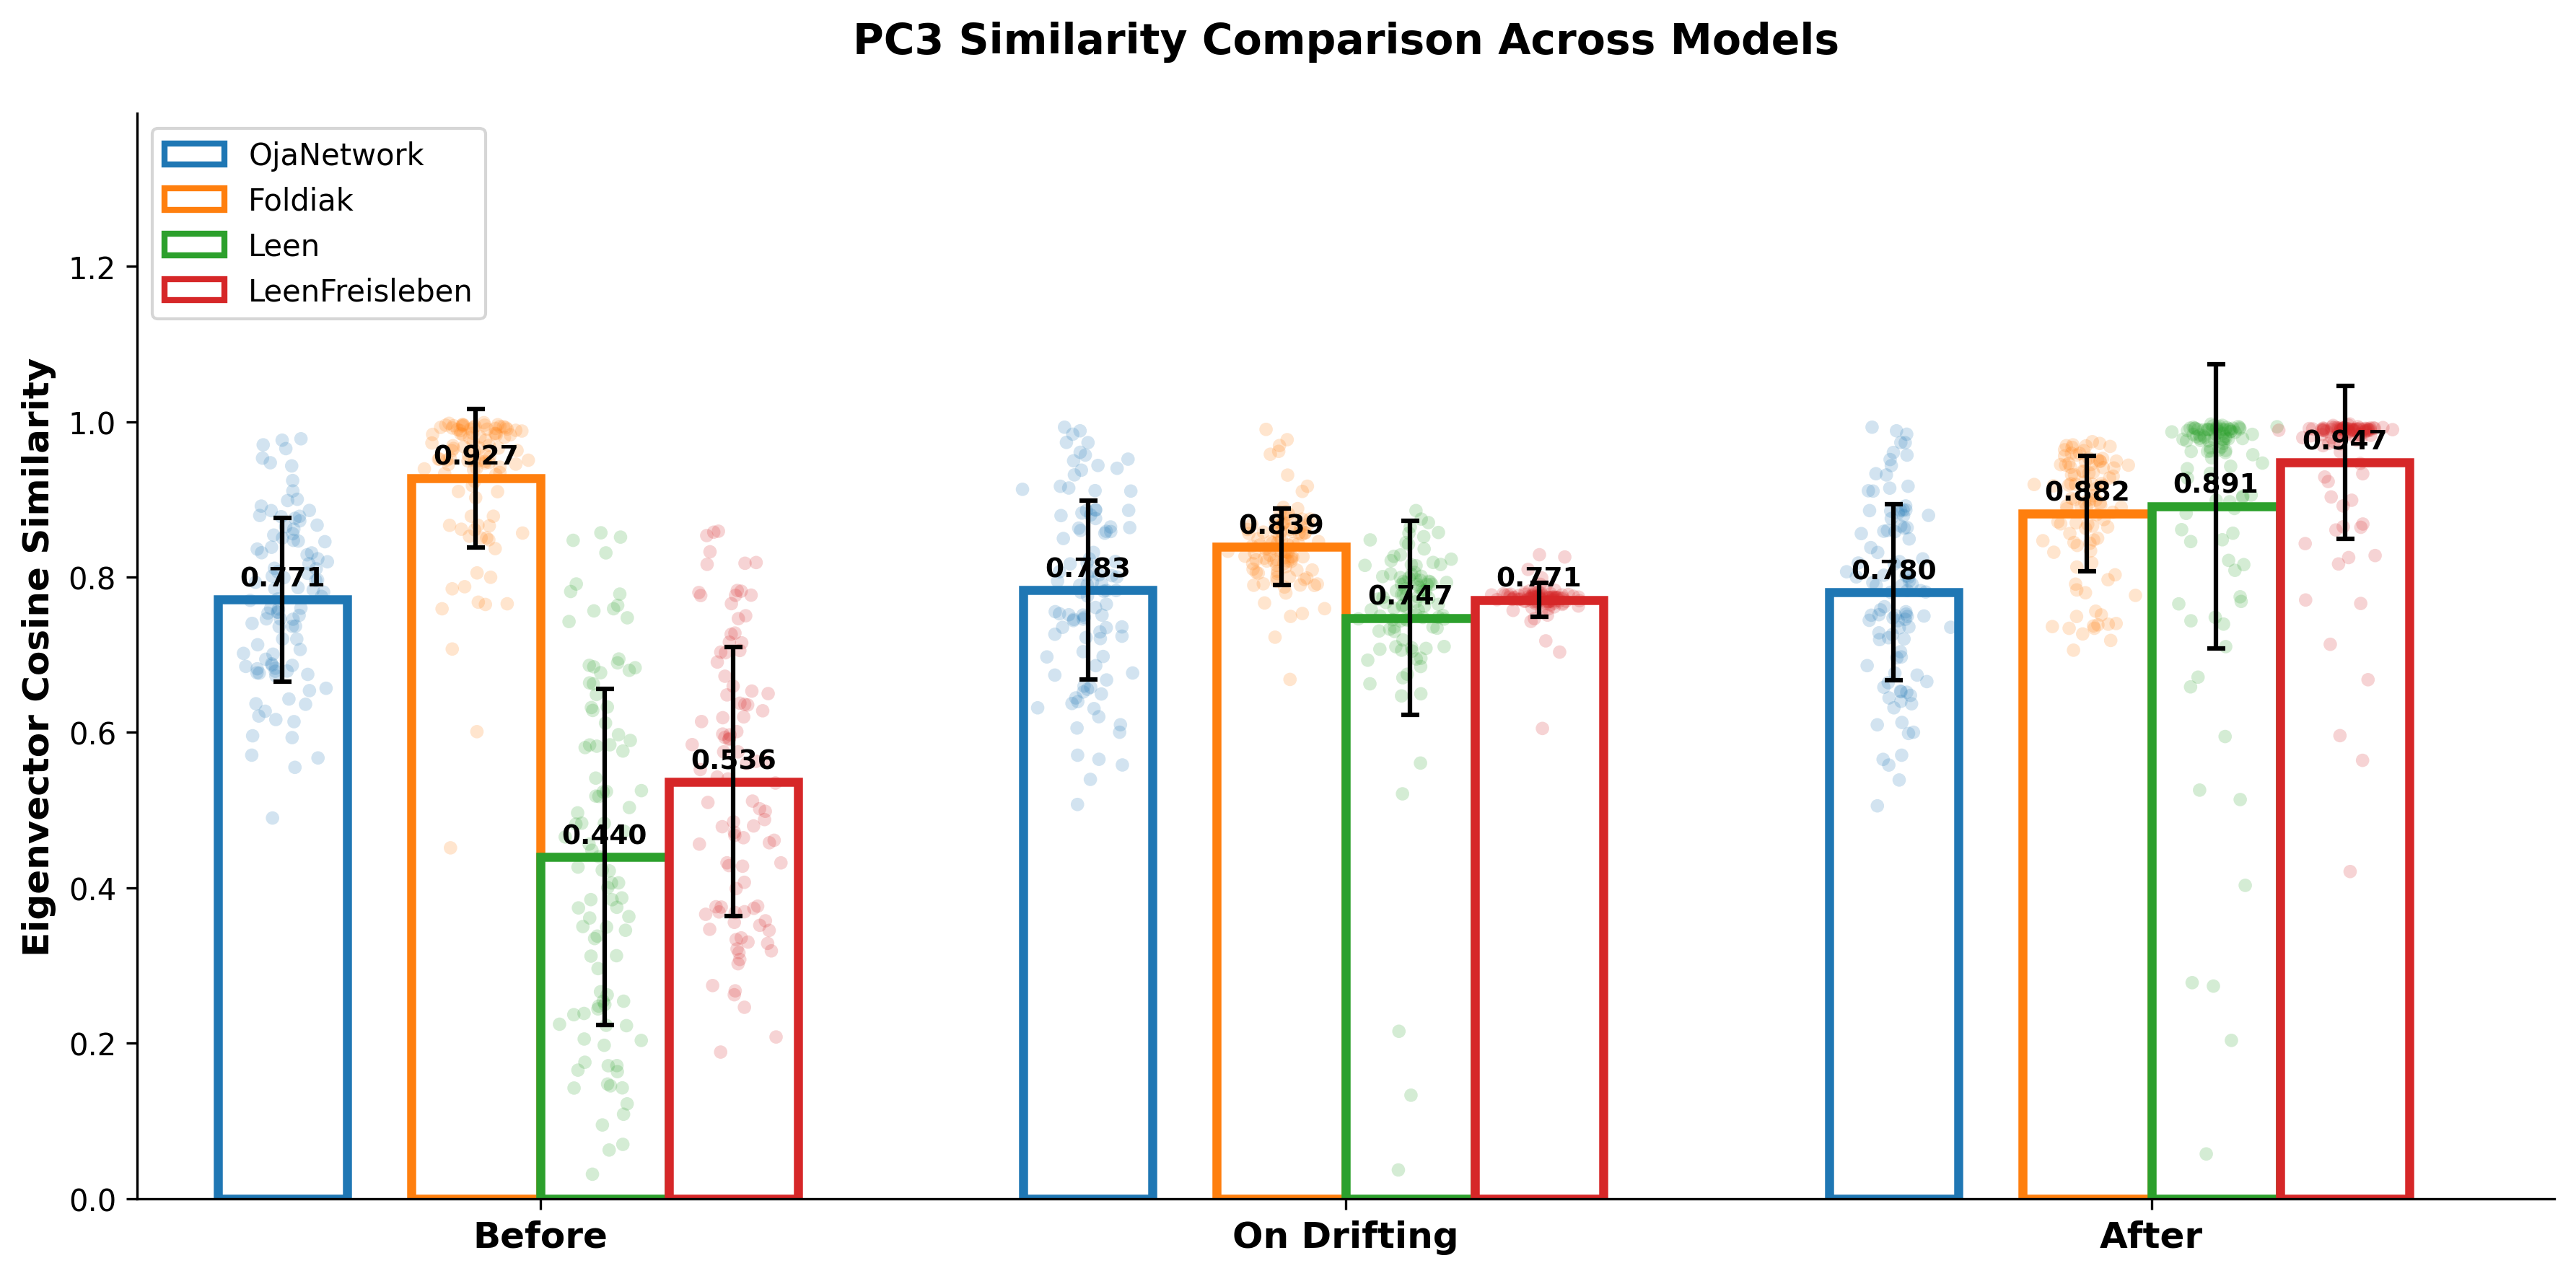

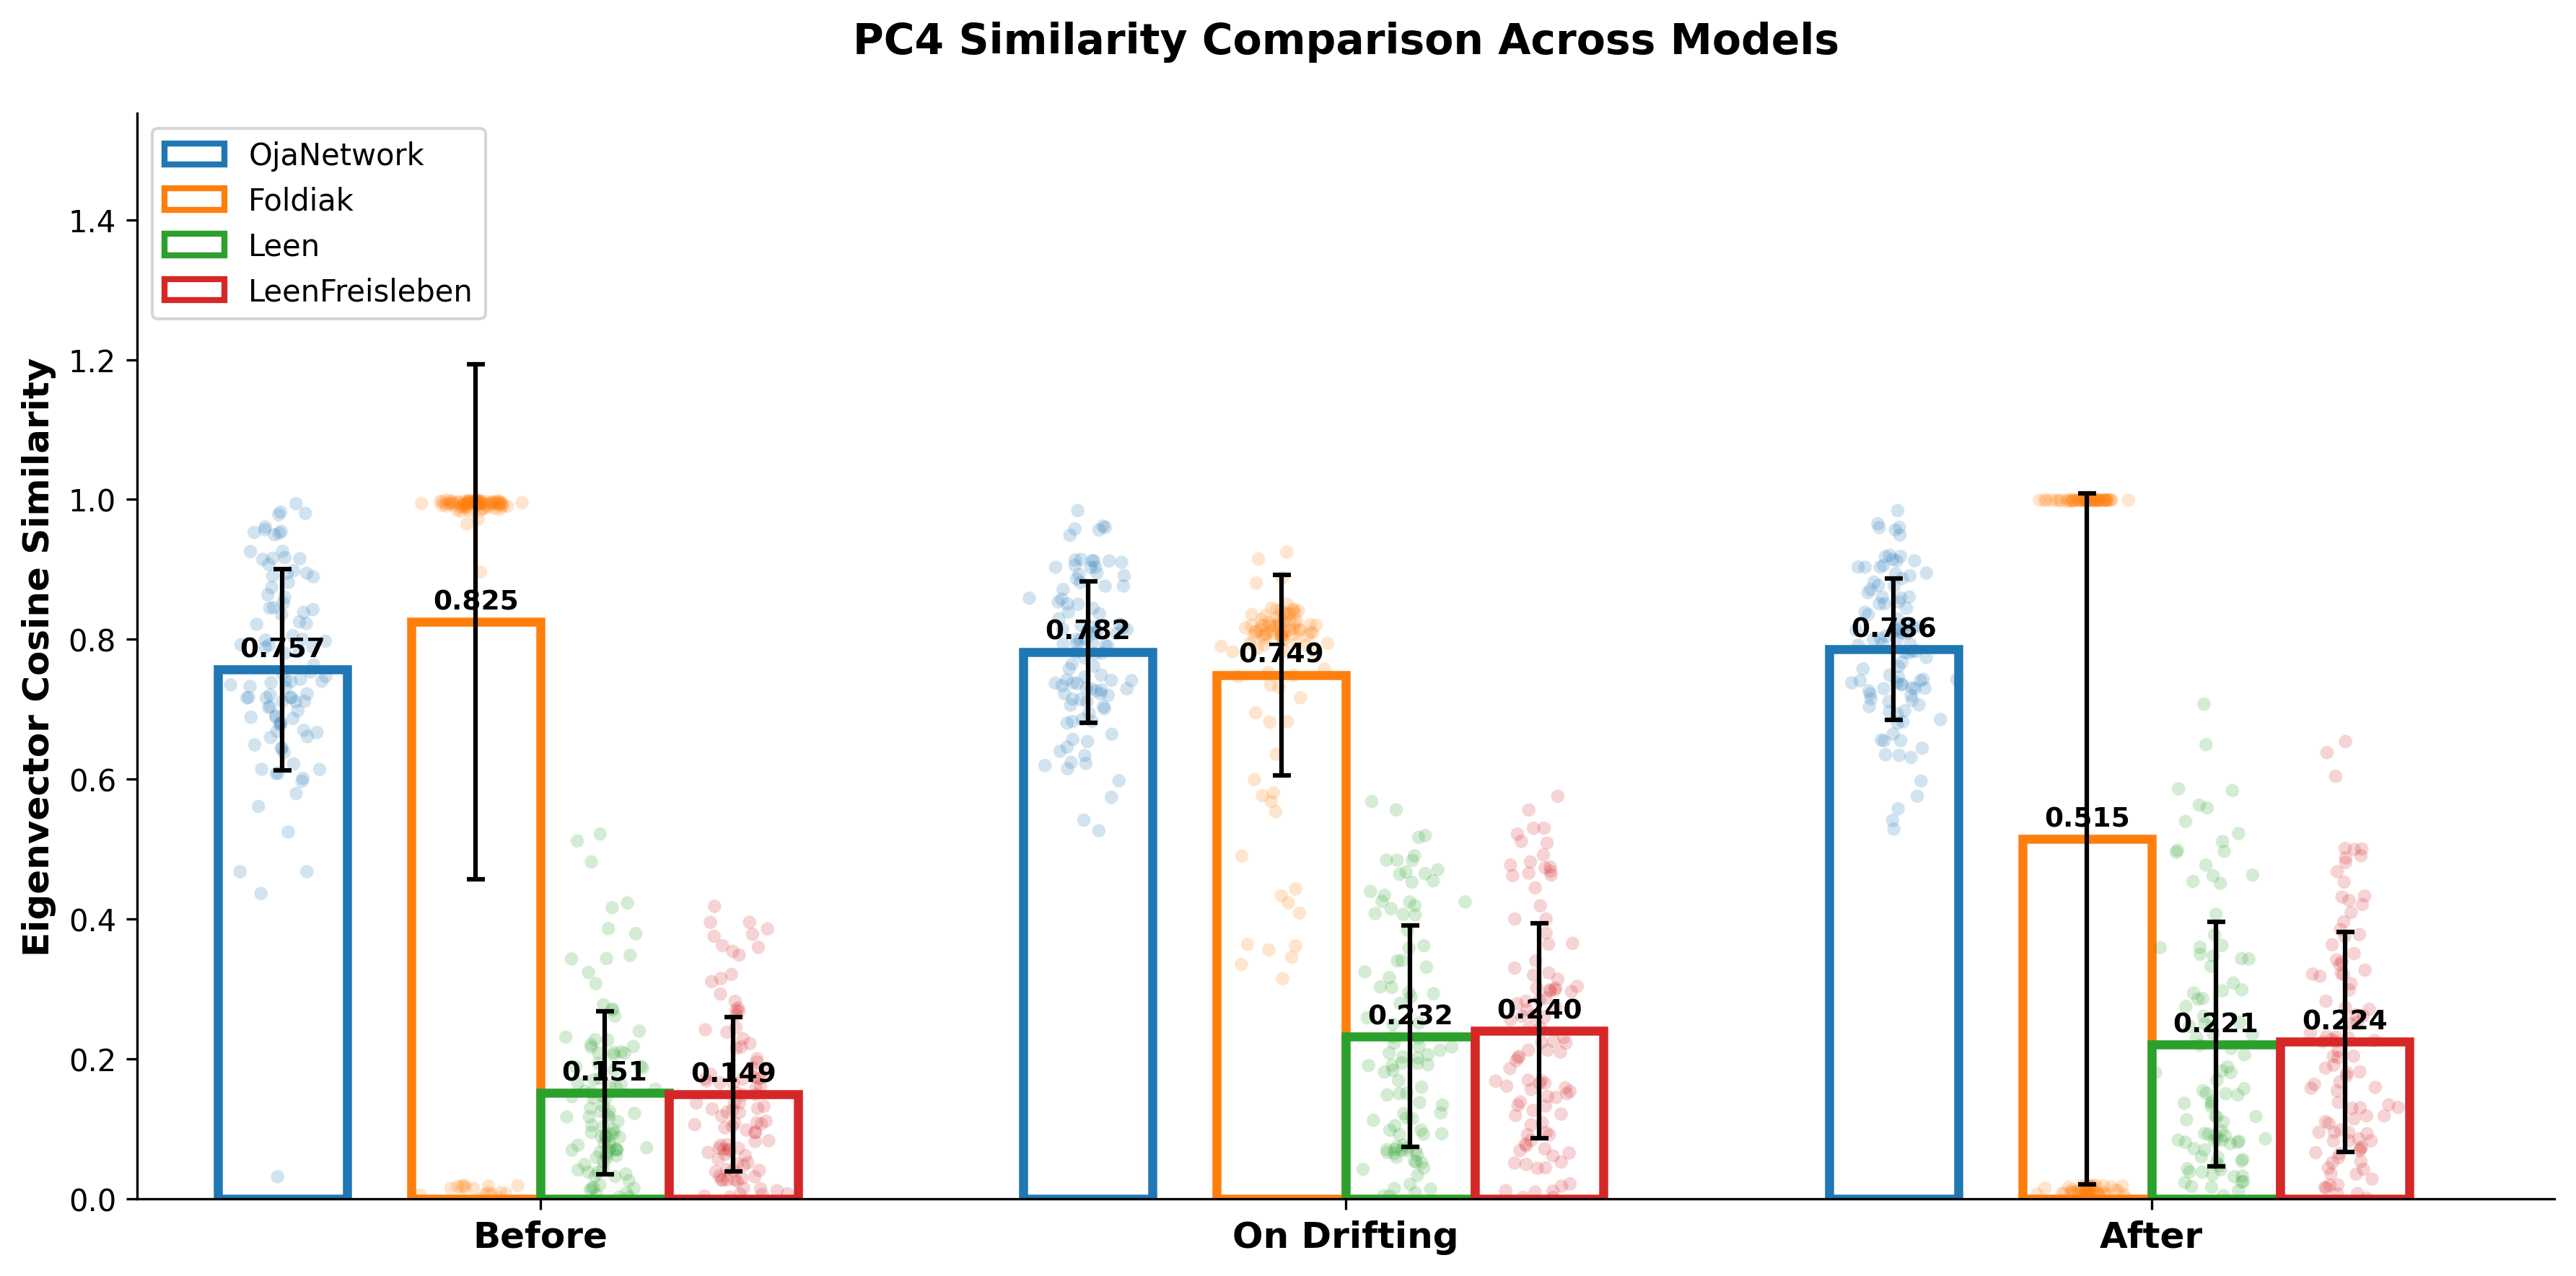

In [ ]:


# Define colors for each model
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red

# Set up positions
n_models = len(model_labels)
n_conditions = 3
condition_labels = ['Before', 'On Drifting', 'After']
bar_width = (0.8 / n_models) * 0.8
group_width = 0.8
group_spacing = 1.0

# Create a separate figure for each PC
for pc_idx in range(n_pcs):
    fig, ax = plt.subplots(1, 1, figsize=(12, 6), dpi=300)
    
    # Calculate x positions for each bar with the custom gap
    x_positions = []
    for cond_idx in range(n_conditions):
        group_center = cond_idx * group_spacing
        pos = group_center - group_width / 2 + bar_width / 2
        for model_idx in range(n_models):
            x_positions.append(pos)
            if model_idx == 0:        # after OjaNetwork
                pos += bar_width + extra_gap
            else:
                pos += bar_width
    
    # Flatten the data for plotting
    all_means = []
    all_stds = []
    all_colors = []
    all_raw_data = []  # Store raw data with corresponding x positions
    
    for cond_idx, cond in enumerate(['before', 'on_drifting', 'after']):
        for model_idx in range(n_models):
            all_means.append(means_by_pc[pc_idx][cond][model_idx])
            all_stds.append(stds_by_pc[pc_idx][cond][model_idx])
            all_colors.append(colors[model_idx])
            # Store raw data with its x position
            x_pos = x_positions[cond_idx * n_models + model_idx]
            all_raw_data.append((x_pos, raw_data_by_pc[pc_idx][cond][model_idx]))
    
    # Create bars with empty fill and colored edges
    bars = ax.bar(x_positions, all_means, yerr=all_stds,
                  width=bar_width,
                  color='white',  # Fill color is white
                  edgecolor=all_colors,  # Edge color matches the original colors
                  linewidth=3.0,  # Make edges more visible
                  alpha=1.0,  # Full opacity for edges
                  capsize=3,
                  error_kw={'elinewidth': 1.5, 'ecolor': 'black', 'capthick': 1.5})
    
    # Add individual data points with jitter
    for x_pos, data_points in all_raw_data:
        # Add small random jitter to x position for better visibility
        jitter = np.random.normal(0, bar_width * 0.15, len(data_points))
        x_scatter = x_pos + jitter
        
        # Find the corresponding color
        idx = x_positions.index(x_pos)
        point_color = all_colors[idx]
        
        # Plot individual points
        ax.scatter(x_scatter, data_points, 
                  color=point_color, 
                  alpha=0.2, 
                  s=20,  # Point size
                  edgecolors='none')  # No edge on points
    
    # Add value labels above error bars
    for bar, mean_val, std_val in zip(bars, all_means, all_stds):
        height = bar.get_height()
        label_y = height + 0.01
        ax.text(bar.get_x() + bar.get_width()/2., label_y,
               f'{mean_val:.3f}',
               ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Set x-axis labels
    group_centers = [i * group_spacing for i in range(n_conditions)]
    ax.set_xticks(group_centers)
    ax.set_xticklabels(condition_labels, fontsize=12, fontweight='bold')
    
    # Add legend for models (updated to show white fill with colored edges)
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='white', edgecolor=colors[i], linewidth=2,
                             label=model_labels[i]) for i in range(n_models)]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
    
    # Customize the plot
    ax.set_ylabel('Eigenvector Cosine Similarity', fontsize=12, fontweight='bold')
    ax.set_title(f'PC{pc_idx + 1} Similarity Comparison Across Models', 
                fontsize=14, fontweight='bold', pad=20)
    max_val = max([m + s for m, s in zip(all_means, all_stds)]) if all_means else 1
    ax.set_ylim([0, max_val * 1.3])
    ax.set_xlim([-0.5, (n_conditions - 1) * group_spacing + 0.5])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# calculate the cosine similarity between pcs before and after
for i in range(m):
    # cosine similarity between pcs before and after
    cosine_similarity_before = np.dot(pcs_before[:, i], pcs_after[:, i]) / (np.linalg.norm(pcs_before[:, i]) * np.linalg.norm(pcs_after[:, i]))
    print(f"Cosine similarity between PC{i+1} before and after: {cosine_similarity_before}")


Cosine similarity between PC1 before and after: 0.34193985837139546
Cosine similarity between PC2 before and after: 0.7893973536055641
Cosine similarity between PC3 before and after: -0.7266631400770128
Cosine similarity between PC4 before and after: 0.4939785923621642


### Sequential execution

In [ ]:
# for model in ['OjaNetwork', 'SangerNetwork', 'FoldiakPCA']: 
#     run_experiment(models[model], data = X_after, 
#                     params=params, task_var=task_var_after, pcs=pcs_after, scores=scores_after, 
#                     batch_size=1, output_size=m, runs=runs)

results_dict = {}
runs = 10
for model in ['SangerNetwork']:
# for model in ['FoldiakPCA']:
    results_dict[model] = decoding_task_variable_optimized_before_after(models[model], data_before=X_before, data_after=X_after, params=params, task_var_before=task_var_before, task_var_after=task_var_after, pcs_before=pcs_before, pcs_after=pcs_after, scores_before=scores_before, scores_after=scores_after, 
                                                            batch_size=1, output_size=m, 
                                                            runs=runs)


Runs: 100%|██████████| 10/10 [00:03<00:00,  3.20it/s]


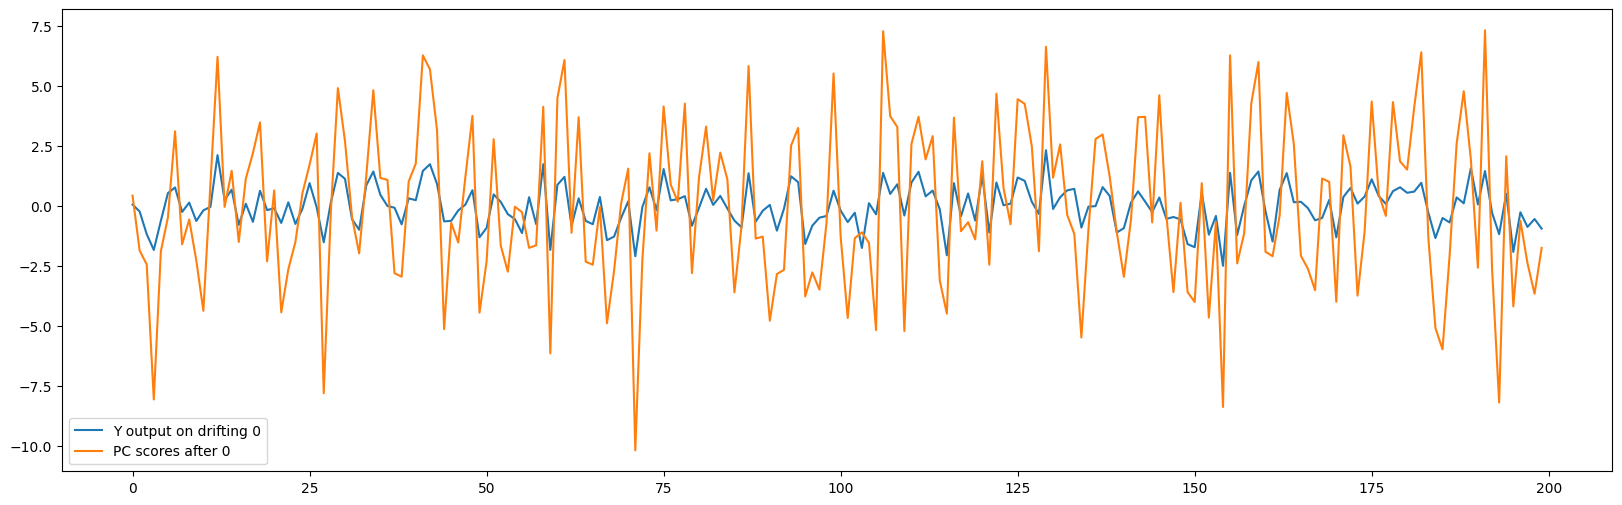

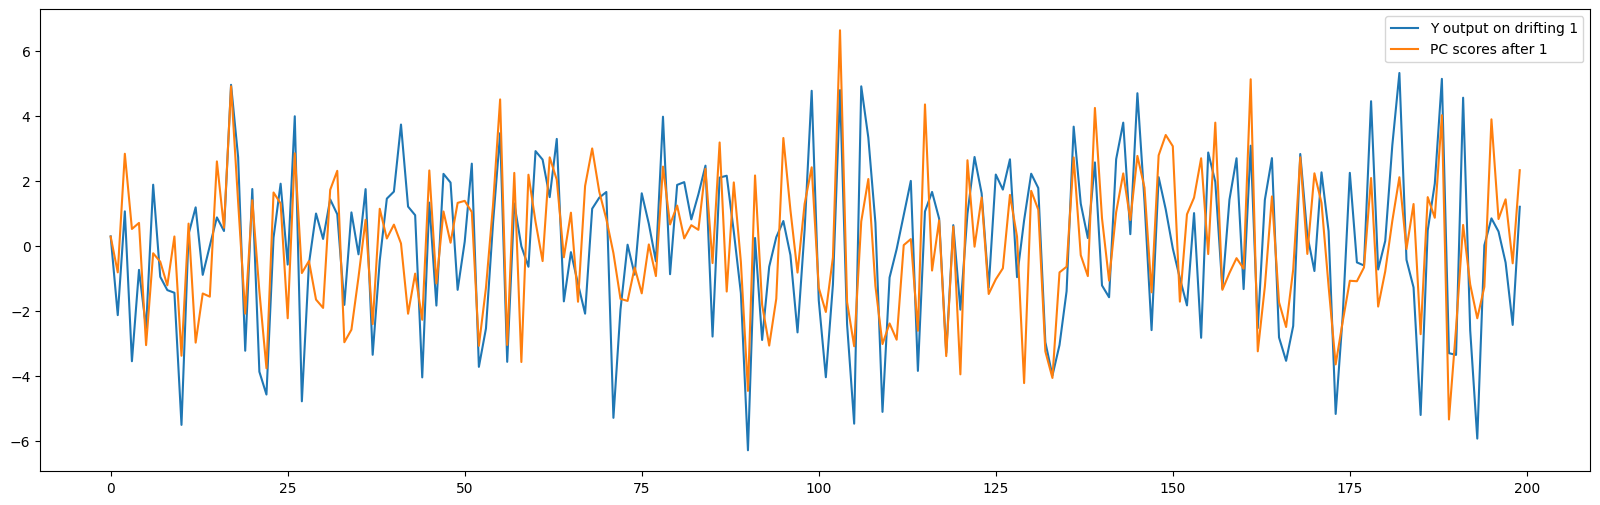

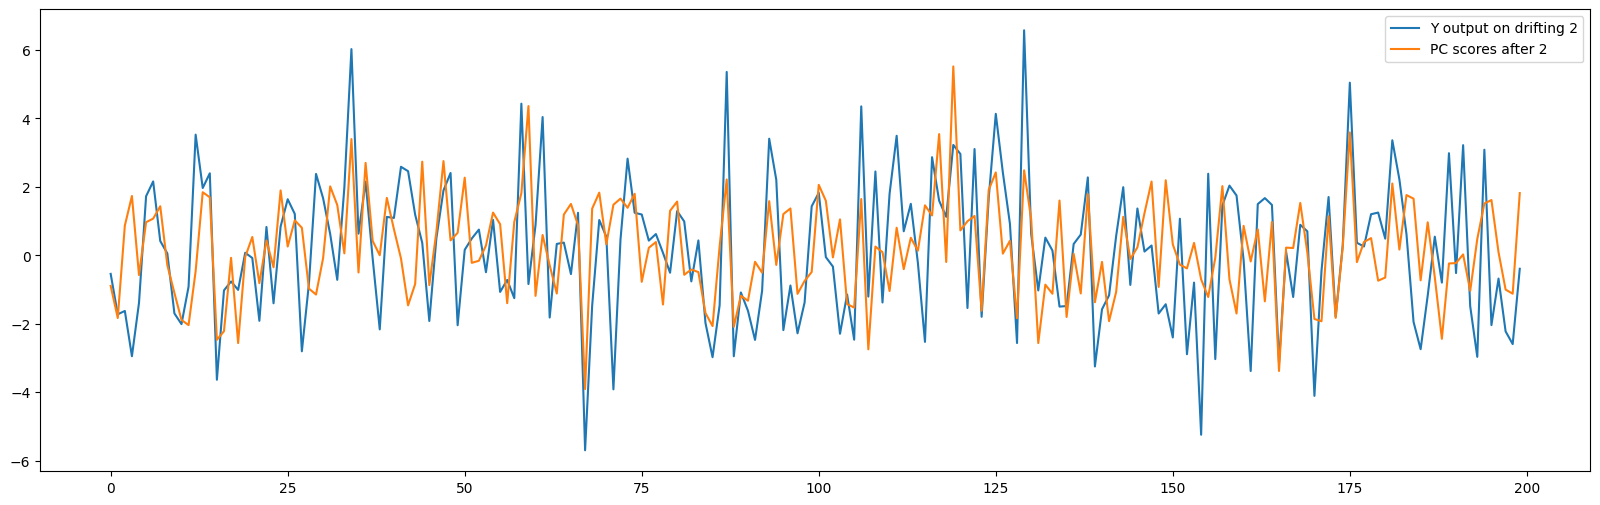

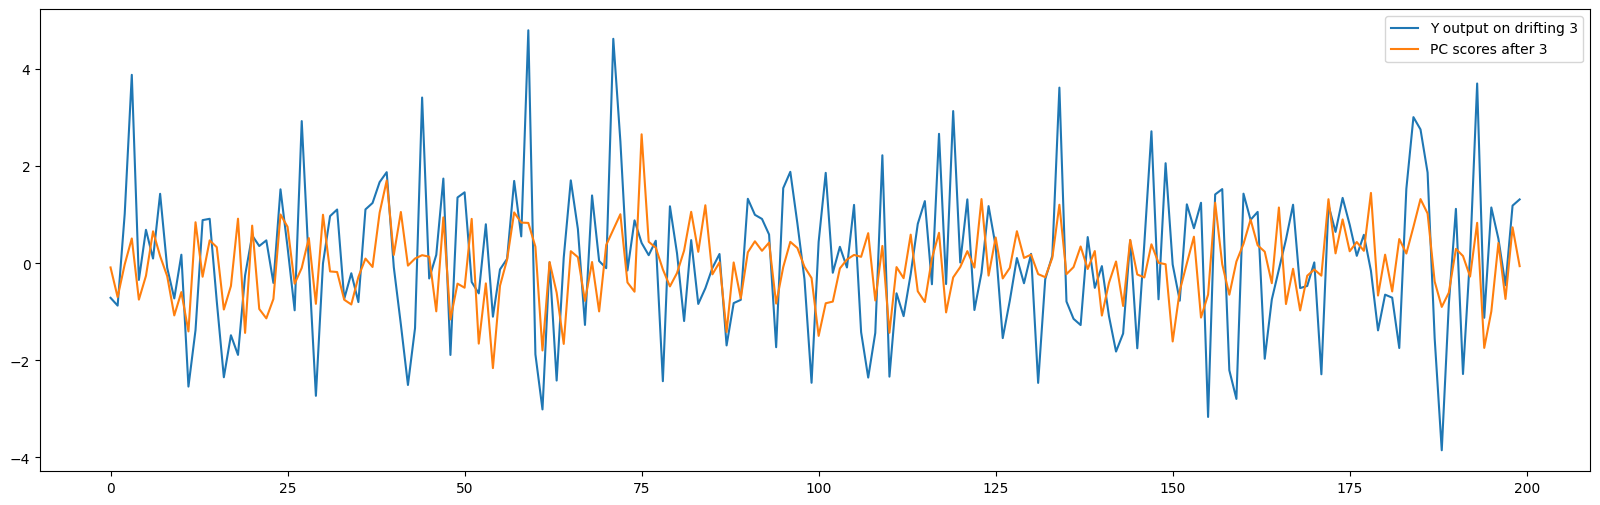

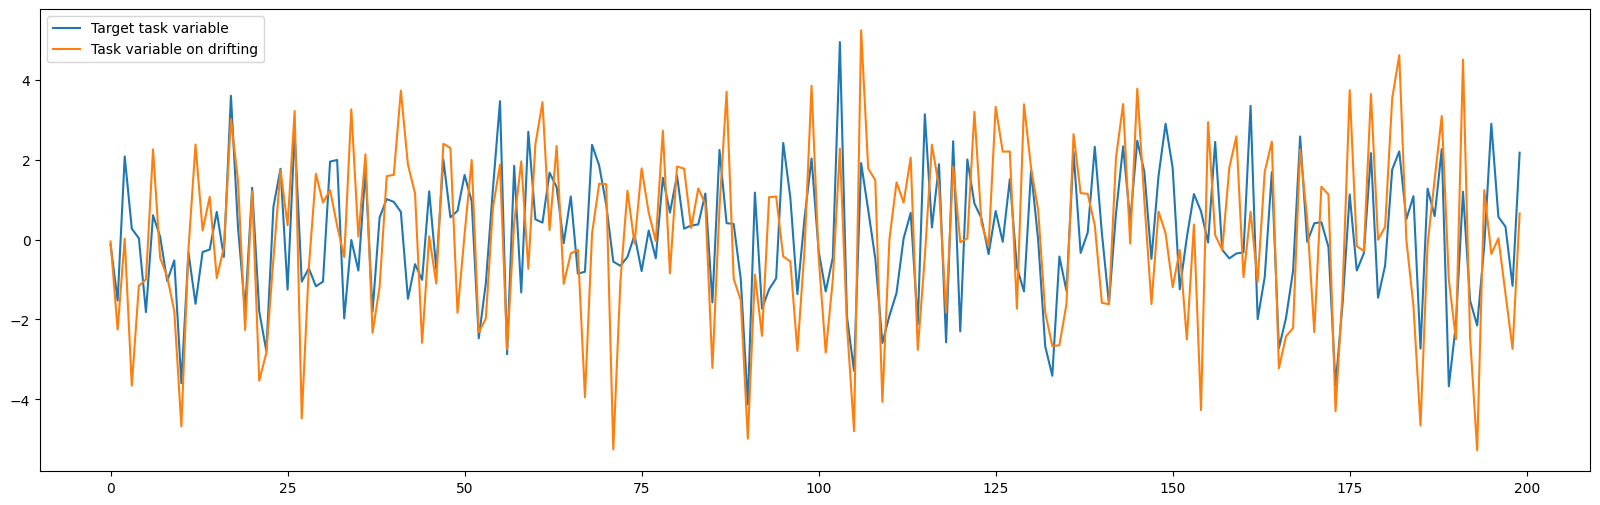

In [ ]:

for i in range(m):
    figure = plt.figure(figsize=(20, 6))
    plt.plot(range(200), Y_output_on_drifiting_signed[:200, i], label=f"Y output on drifting {i}")
    plt.plot(range(200), scores_after[:200, i], label=f"PC scores after {i}")
    plt.legend()
plt.show()


figure = plt.figure(figsize=(20, 6))
plt.plot(range(200), task_var_after[:200], label="Target task variable")
plt.plot(range(200), task_var_on_drifiting_tilde[:200], label="Task variable on drifting")
plt.legend()
plt.show()




### Bar graph for model performance

Data before the drift:
- Step 1: Runs the model, and get the response (Y_output)
- Step 2: 
    - OjaNetwork: to decode the task variable, do linear regression to get the weight vector
    - FoldiakPCA: same to OjaNetwork
    - Leen's complete PCA: same to OjaNetwork in this case
    
Data after the drift:
- Step 1: Runs the model, and get the response (Y_output)
- Step 2: 
    - OjaNetwork: to decode the task variable, however, using the previous weight
    - FoldiakPCA: same to OjaNetwork, using the previous weight
    - Leen's complete PCA: same to OjaNetwork in this case using the previous weight